# 📊 Notebook 04 — EDA: Tabular

<div style="border-left: 4px solid #4680a7; padding: 10px 15px; margin: 10px 0; background: #4e6681;">

**Objective:** Conduct comprehensive exploratory data analysis on the **tabular (structured) features** of the cleaned dataset. Generate statistical summaries, distribution profiles, correlation analyses, and bivariate analyses against `AdoptionSpeed`.

**Answers:** *"What patterns exist in the structured data that may predict adoption speed?"*

</div>

| Item | Detail |
|------|--------|
| **Dependencies** | `data/cleaned/train.parquet`, reference tables (`breed_labels`, `color_labels`, `state_labels`) |
| **Artifacts** | `reports/figures/eda_tabular/*.png`, `reports/eda_tabular_findings.json` |
| **Scope** | Tabular features only — no text, image, or metadata analysis |
| **Runtime** | ~2 min |

---
## 1. Imports & Configuration

In [ ]:
# ── Standard library & third-party imports ──────────────────────────
from __future__ import annotations

import json
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

# ── Project imports ─────────────────────────────────────────────────
from adoption_accelerator import config as cfg
from adoption_accelerator.data.ingestion import load_parquet, load_reference_table
from adoption_accelerator.utils.visualization import (
    ADOPTION_SPEED_LABELS,
    ADOPTION_SPEED_PALETTE,
    compute_cramers_v,
    compute_cramers_v_matrix,
    compute_descriptive_stats,
    plot_categorical_distribution,
    plot_correlation_matrix,
    plot_numeric_distribution,
    plot_target_distribution,
    save_figure,
)

# ── Reproducibility & display ───────────────────────────────────────
SEED = cfg.SEED
np.random.seed(SEED)
random.seed(SEED)

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 60)
pd.set_option("display.float_format", "{:.3f}".format)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 150, "figure.facecolor": "white"})

# ── Ensure output directory exists ──────────────────────────────────
FIGURES_DIR = cfg.REPORTS_FIGURES / "eda_tabular"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Track saved figures for validation gate
saved_figures: list[Path] = []

print("✅ Imports and configuration loaded.")
print(f"   Seed: {SEED}")
print(f"   Figures dir: {FIGURES_DIR}")

✅ Imports and configuration loaded.
   Seed: 42
   Figures dir: C:\Projects\Personal_Projects\AI_Adoption_Acceleration\adoption_accelerator\reports\figures\eda_tabular


---
## 2. Load Cleaned Data & Reference Tables

In [ ]:
# ── Load cleaned training data ──────────────────────────────────────
train = load_parquet(cfg.DATA_CLEANED / "train.parquet")

# ── Load reference tables ──────────────────────────────────────────
ref_breeds = load_reference_table("breed")
ref_colors = load_reference_table("color")
ref_states = load_reference_table("state")

# ── Quick preview ──────────────────────────────────────────────────
print(f"Train shape: {train.shape}")
train.head()

Train shape: (14993, 25)


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed,has_name
0,2,Nibble,3,299,0,1,1,7,0,1,1,2,2,2,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.000,2,1
1,2,NaN,1,265,0,1,1,2,0,2,2,3,3,3,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.000,0,0
2,1,Brisco,1,307,0,1,2,7,0,2,2,1,1,2,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.000,3,1
3,1,Miko,4,307,0,2,1,2,0,2,1,1,1,2,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.000,2,1
4,1,Hunter,1,307,0,1,1,0,0,2,1,2,2,2,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.000,2,1


In [ ]:
# ── Validation Gate G04-1: Shape & columns ─────────────────────────
EXPECTED_COLS = {
    "Type", "Name", "Age", "Breed1", "Breed2", "Gender",
    "Color1", "Color2", "Color3", "MaturitySize", "FurLength",
    "Vaccinated", "Dewormed", "Sterilized", "Health",
    "Quantity", "Fee", "State", "RescuerID", "VideoAmt",
    "Description", "PetID", "PhotoAmt", "AdoptionSpeed", "has_name",
}

missing_cols = EXPECTED_COLS - set(train.columns)
assert len(missing_cols) == 0, f"G04-1 FAIL: Missing columns: {missing_cols}"

# ── Validation Gate G04-2: All 5 AdoptionSpeed classes present ─────
classes_present = set(train["AdoptionSpeed"].unique())
assert classes_present == {0, 1, 2, 3, 4}, f"G04-2 FAIL: Classes found: {classes_present}"

# Record initial NaN count for integrity check later
initial_nan_count = int(train.isna().sum().sum())

print("✅ G04-1: All expected columns present.")
print("✅ G04-2: All 5 AdoptionSpeed classes present.")
print(f"   Initial NaN count: {initial_nan_count}")

✅ G04-1: All expected columns present.
✅ G04-2: All 5 AdoptionSpeed classes present.
   Initial NaN count: 1433



---
## 3. Target Variable Analysis — `AdoptionSpeed`

<div style="border-left: 4px solid #e74c3c; padding: 8px 12px; margin: 8px 0; background: #5e4848;">

**Target:** Ordinal multiclass variable (0–4) representing adoption speed. Class imbalance and ordinal structure are key considerations for model selection.

</div>

,count,proportion_%
AdoptionSpeed,,
0,410,2.730
1,3090,20.610
2,4037,26.930
3,3259,21.740
4,4197,27.990



Imbalance ratio (max / min class): 10.24
Majority class: 4 (100+ days)
Minority class: 0 (Same day)


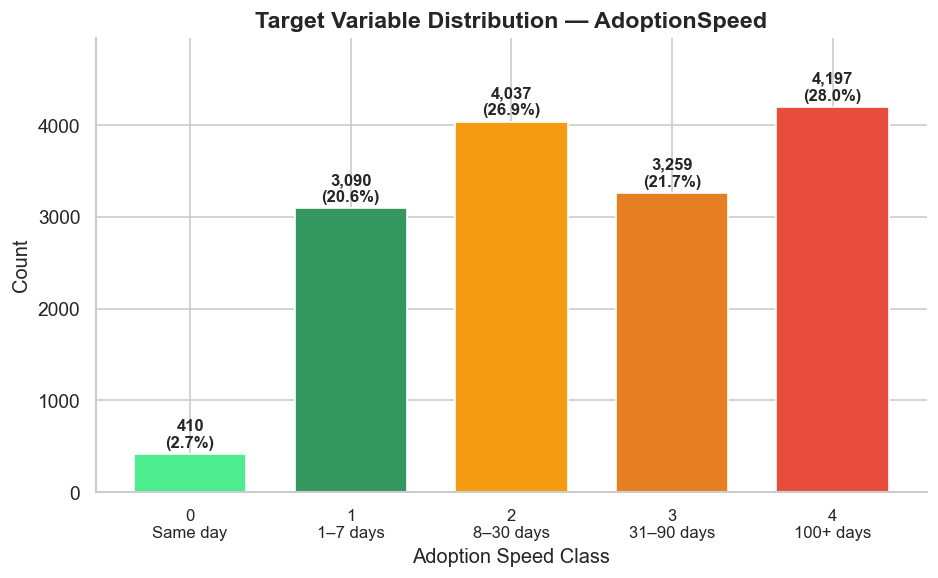

In [ ]:
# ── Target class distribution ───────────────────────────────────────
target = train["AdoptionSpeed"]
counts = target.value_counts().sort_index()
proportions = (counts / len(target) * 100).round(2)

target_summary = pd.DataFrame({"count": counts, "proportion_%": proportions})
target_summary.index.name = "AdoptionSpeed"
display(target_summary)

# Imbalance ratio
imbalance_ratio = counts.max() / counts.min()
print(f"\nImbalance ratio (max / min class): {imbalance_ratio:.2f}")
print(f"Majority class: {counts.idxmax()} ({ADOPTION_SPEED_LABELS[counts.idxmax()]})")
print(f"Minority class: {counts.idxmin()} ({ADOPTION_SPEED_LABELS[counts.idxmin()]})")

# ── Plot ────────────────────────────────────────────────────────────
fig = plot_target_distribution(target)
saved_figures.append(save_figure(fig, "target_distribution"))
plt.show()

---
## 4. Univariate Analysis — Numeric Features

Analysis of `Age`, `Fee`, `Quantity`, `PhotoAmt`, `VideoAmt`: descriptive statistics, distributions, and outliers.

In [ ]:
NUMERIC_COLS = ["Age", "Fee", "Quantity", "PhotoAmt", "VideoAmt"]

# ── Descriptive statistics ──────────────────────────────────────────
desc_stats = compute_descriptive_stats(train, NUMERIC_COLS)
display(desc_stats.style.format("{:.2f}").set_caption("Descriptive Statistics — Numeric Features"))

# ── Outlier detection (IQR method) ─────────────────────────────────
outlier_records = []
for col in NUMERIC_COLS:
    s = train[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = int(((s < lower) | (s > upper)).sum())
    outlier_records.append({
        "feature": col,
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "IQR": round(iqr, 2),
        "lower_bound": round(lower, 2),
        "upper_bound": round(upper, 2),
        "n_outliers": n_outliers,
        "pct_outliers": round(n_outliers / len(s) * 100, 2),
    })

outlier_df = pd.DataFrame(outlier_records).set_index("feature")
display(outlier_df.style.format("{:.2f}").set_caption("Outlier Summary (IQR Method)"))

,count,mean,median,std,min,max,skewness,kurtosis
Age,14993.00,10.45,3.00,18.16,0.00,255.00,3.76,20.77
Fee,14993.00,21.26,0.00,78.41,0.00,3000.00,8.92,191.70
Quantity,14993.00,1.58,1.00,1.47,1.00,20.00,4.60,34.09
PhotoAmt,14993.00,3.89,3.00,3.49,0.00,30.00,2.86,12.65
VideoAmt,14993.00,0.06,0.00,0.35,0.00,8.00,9.46,124.42


,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers,pct_outliers
feature,,,,,,,
Age,2.00,12.00,10.00,-13.00,27.00,1501.00,10.01
Fee,0.00,0.00,0.00,0.00,0.00,2330.00,15.54
Quantity,1.00,1.00,0.00,1.00,1.00,3428.00,22.86
PhotoAmt,2.00,5.00,3.00,-2.50,9.50,922.00,6.15
VideoAmt,0.00,0.00,0.00,0.00,0.00,574.00,3.83


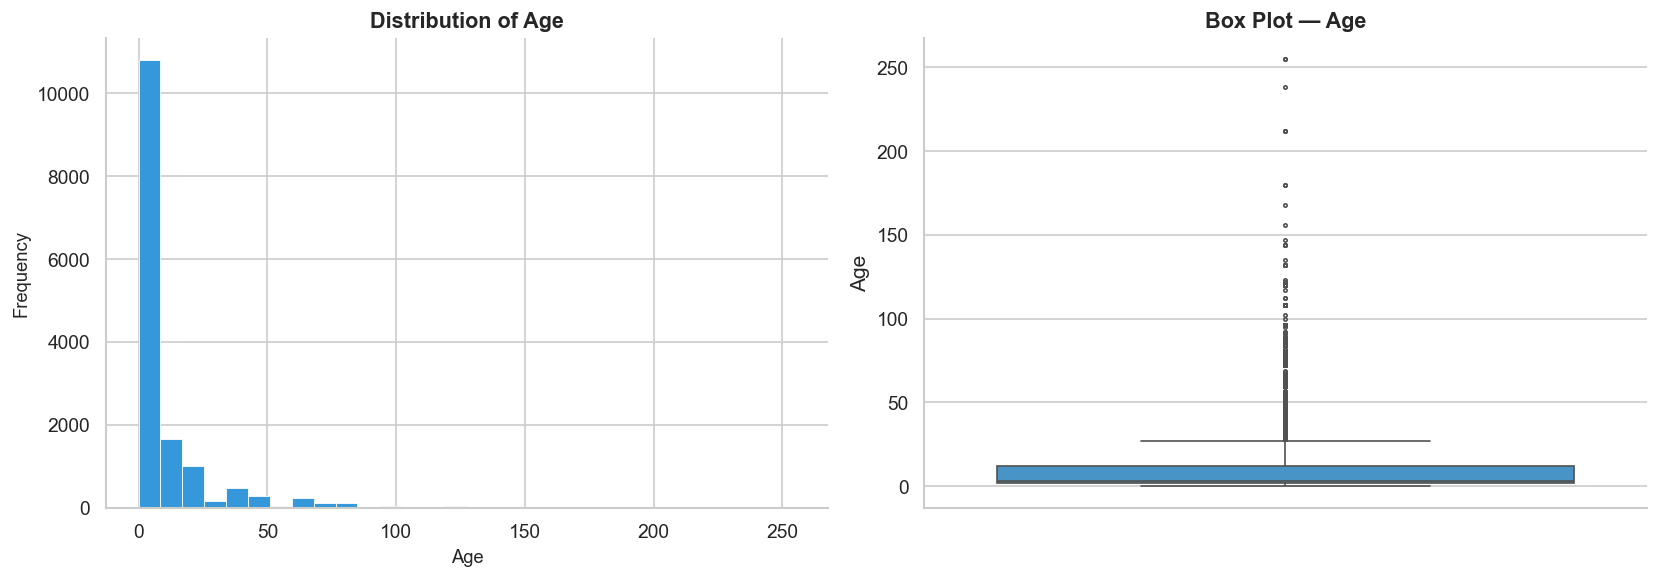

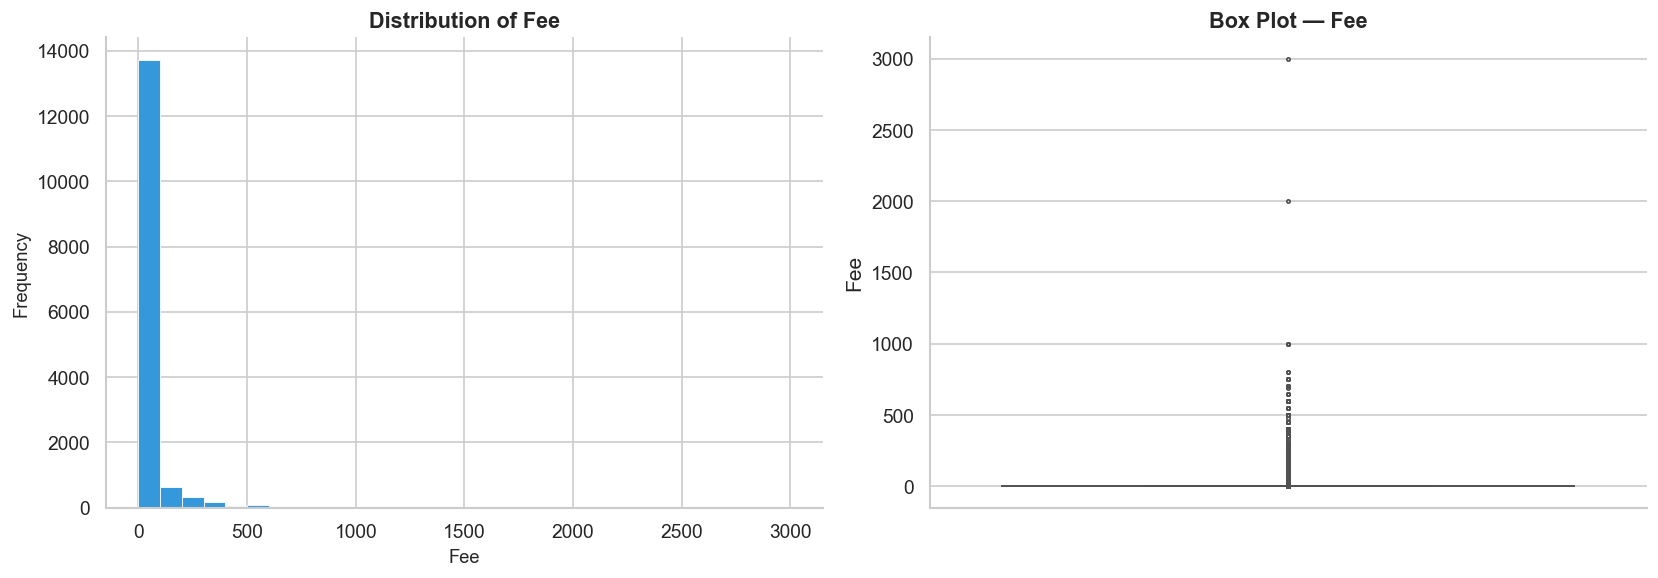

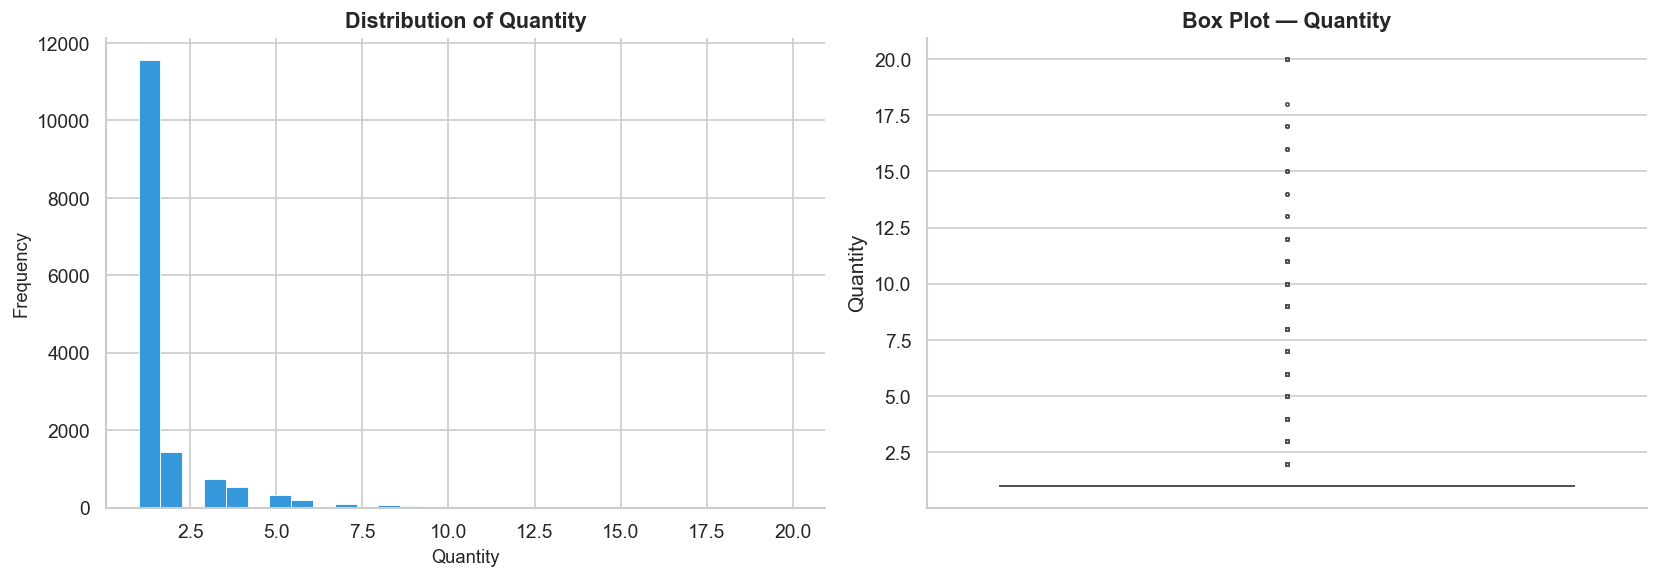

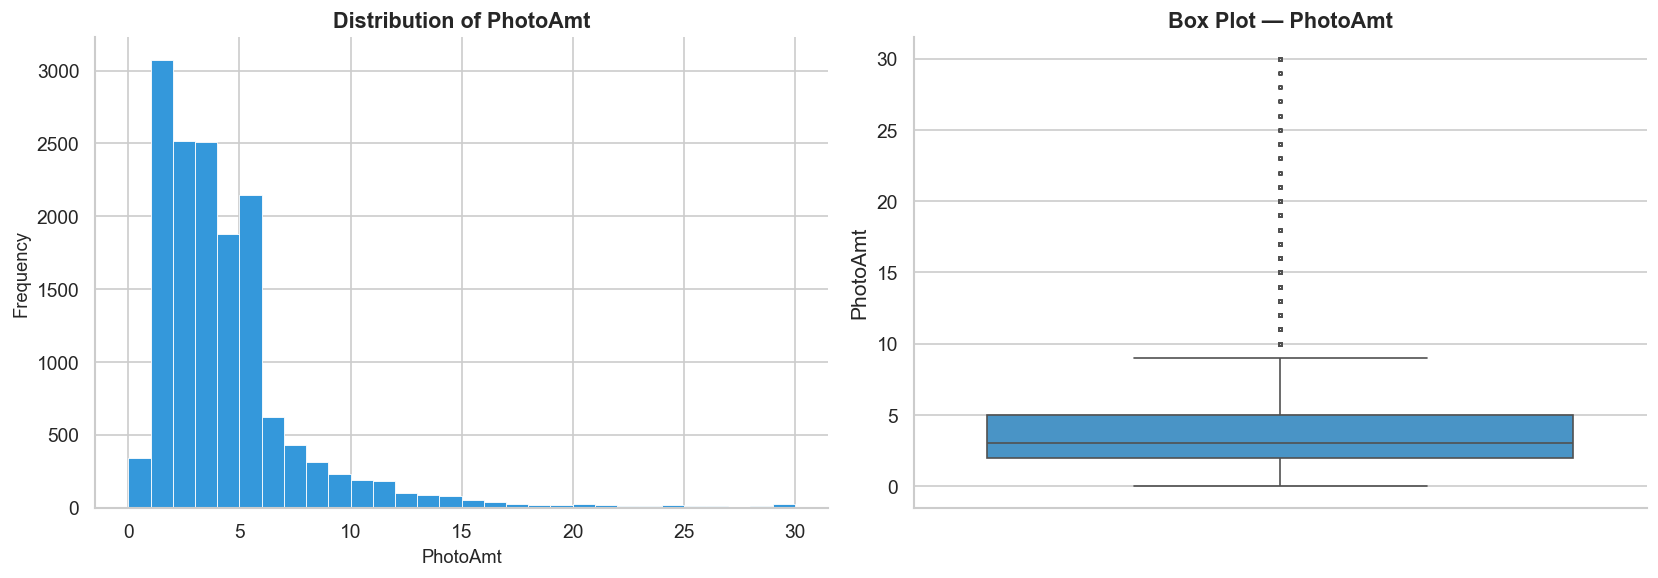

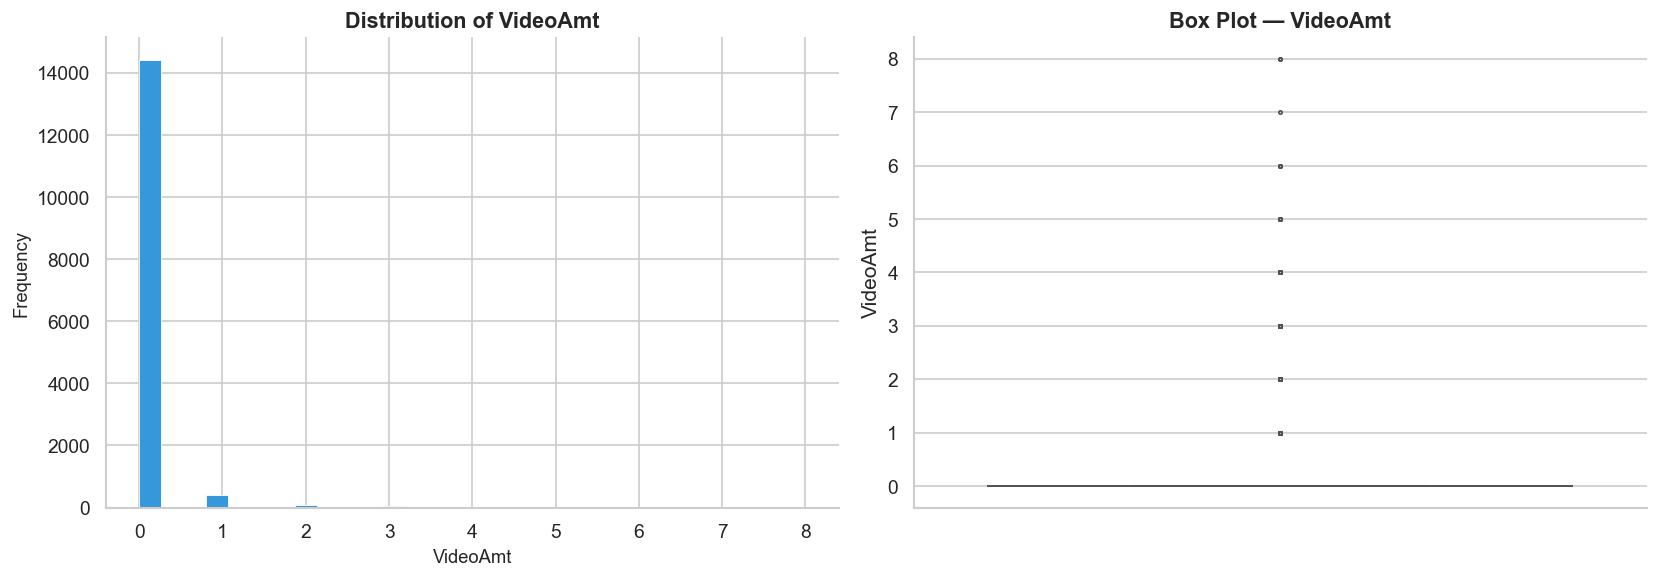

In [ ]:
# ── Distribution plots for each numeric feature ────────────────────
for col in NUMERIC_COLS:
    fig = plot_numeric_distribution(train, col)
    saved_figures.append(save_figure(fig, f"univariate_{col.lower()}"))
    plt.show()

---
## 5. Univariate Analysis — Categorical Features

Analysis of `Type`, `Gender`, `MaturitySize`, `FurLength`, `Vaccinated`, `Dewormed`, `Sterilized`, `Health`.

In [ ]:
CATEGORICAL_COLS = ["Type", "Gender", "MaturitySize", "FurLength",
                    "Vaccinated", "Dewormed", "Sterilized", "Health"]

LABEL_MAPS = {
    "Type": {1: "Dog", 2: "Cat"},
    "Gender": {1: "Male", 2: "Female", 3: "Mixed"},
    "MaturitySize": {0: "Not Spec.", 1: "Small", 2: "Medium", 3: "Large", 4: "Extra Large"},
    "FurLength": {0: "Not Spec.", 1: "Short", 2: "Medium", 3: "Long"},
    "Vaccinated": {1: "Yes", 2: "No", 3: "Not Sure"},
    "Dewormed": {1: "Yes", 2: "No", 3: "Not Sure"},
    "Sterilized": {1: "Yes", 2: "No", 3: "Not Sure"},
    "Health": {1: "Healthy", 2: "Minor Injury", 3: "Serious Injury"},
}

# ── Value counts summary ───────────────────────────────────────────
for col in CATEGORICAL_COLS:
    vc = train[col].value_counts().sort_index()
    pct = (vc / len(train) * 100).round(1)
    summary = pd.DataFrame({"count": vc, "%": pct})
    if col in LABEL_MAPS:
        summary.index = summary.index.map(lambda x: f"{x} ({LABEL_MAPS[col].get(x, x)})")
    print(f"\n{'─'*50}")
    print(f"  {col}")
    print(f"{'─'*50}")
    display(summary)


──────────────────────────────────────────────────
  Type
──────────────────────────────────────────────────


,count,%
Type,,
1 (Dog),8132,54.200
2 (Cat),6861,45.800



──────────────────────────────────────────────────
  Gender
──────────────────────────────────────────────────


,count,%
Gender,,
1 (Male),5536,36.900
2 (Female),7277,48.500
3 (Mixed),2180,14.500



──────────────────────────────────────────────────
  MaturitySize
──────────────────────────────────────────────────


...

,count,%
Dewormed,,
1 (Yes),8397,56.000
2 (No),4815,32.100
3 (Not Sure),1781,11.900



──────────────────────────────────────────────────
  Sterilized
──────────────────────────────────────────────────


,count,%
Sterilized,,
1 (Yes),3101,20.700
2 (No),10077,67.200
3 (Not Sure),1815,12.100



──────────────────────────────────────────────────
  Health
──────────────────────────────────────────────────


,count,%
Health,,
1 (Healthy),14478,96.600
2 (Minor Injury),481,3.200
3 (Serious Injury),34,0.200


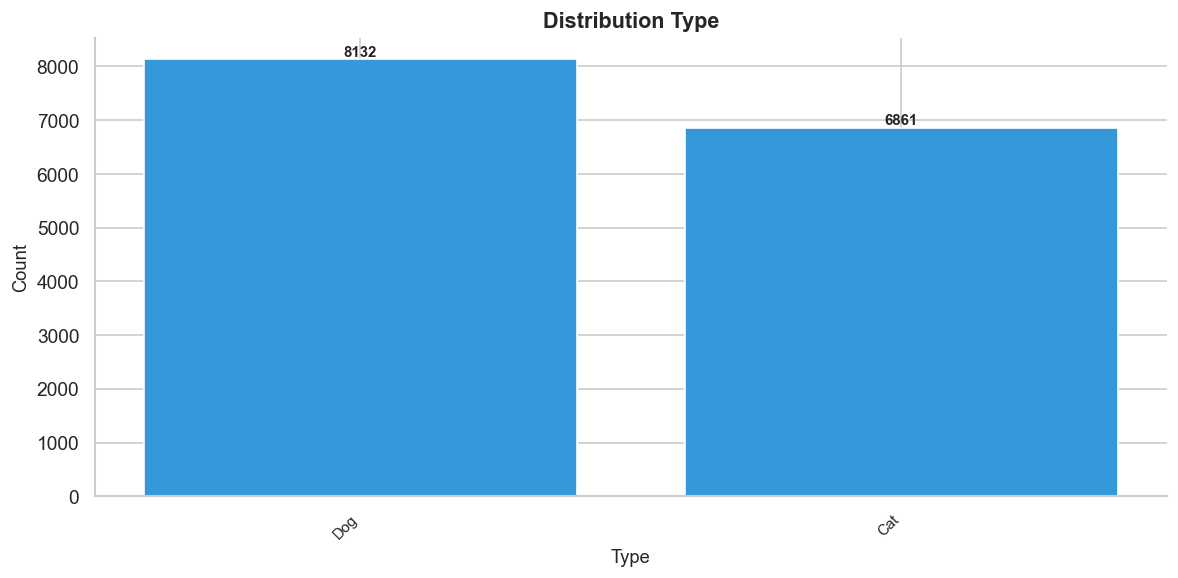

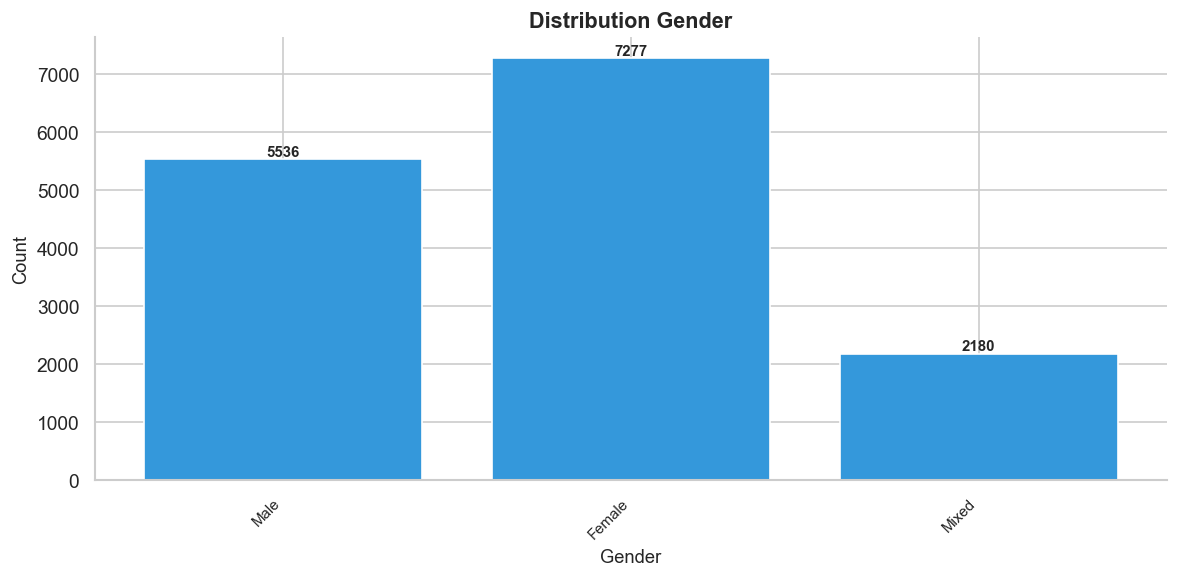

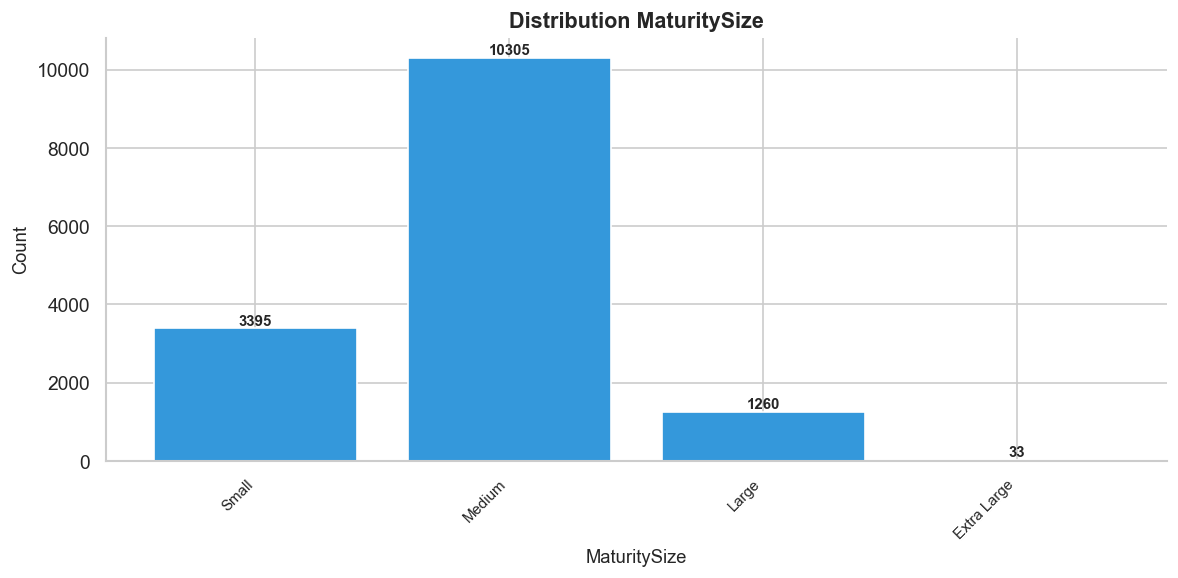

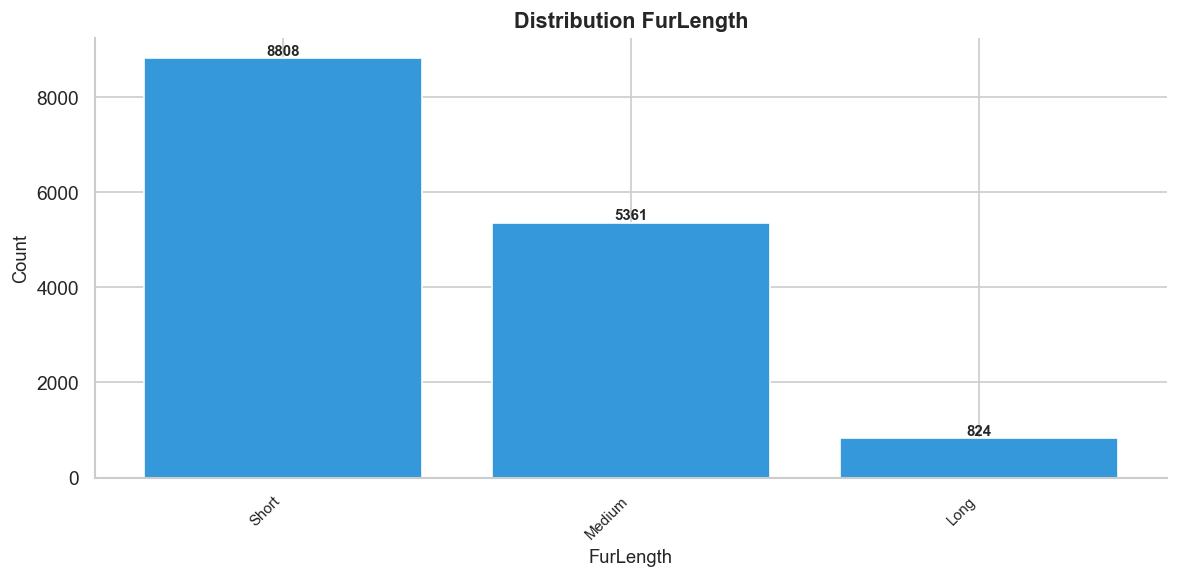

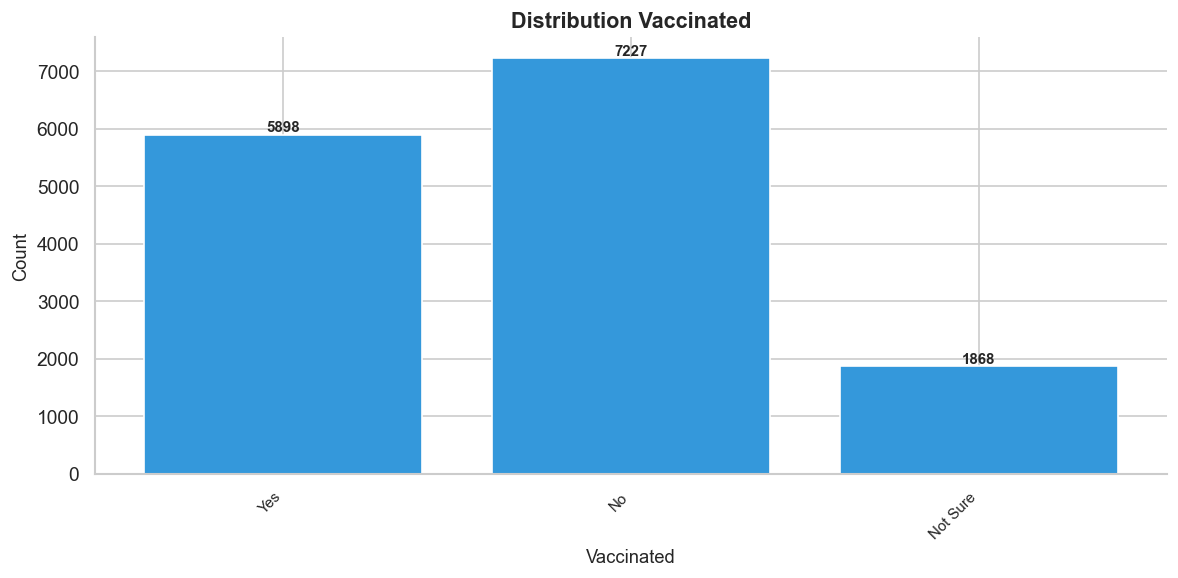

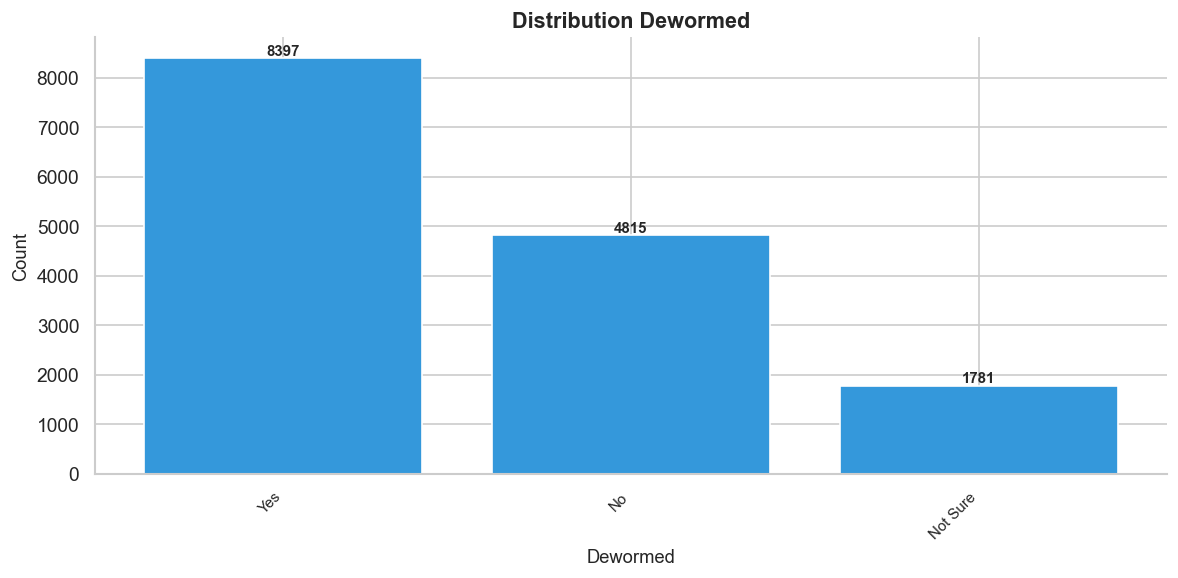

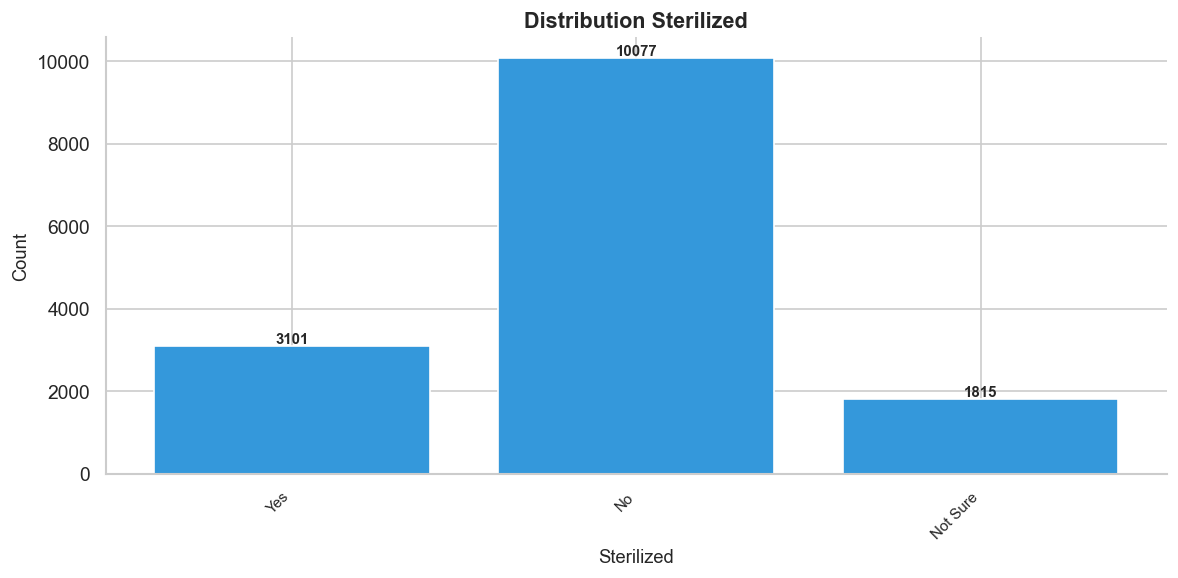

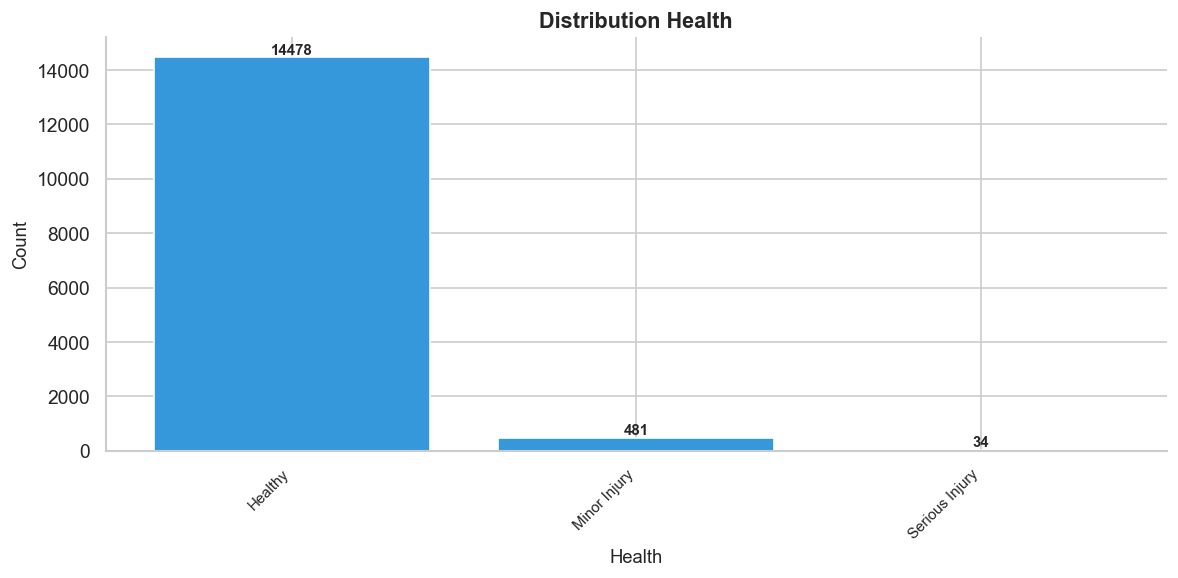

In [ ]:
# ── Bar charts for each categorical feature ─────────────────────────
for col in CATEGORICAL_COLS:
    fig = plot_categorical_distribution(
        train, col, label_map=LABEL_MAPS.get(col)
    )
    saved_figures.append(save_figure(fig, f"univariate_{col.lower()}"))
    plt.show()

---
## 6. Univariate Analysis — High-Cardinality Features

Top-N analysis for `Breed1`, `Breed2`, `State`, `Color1`. Long-tail identification.

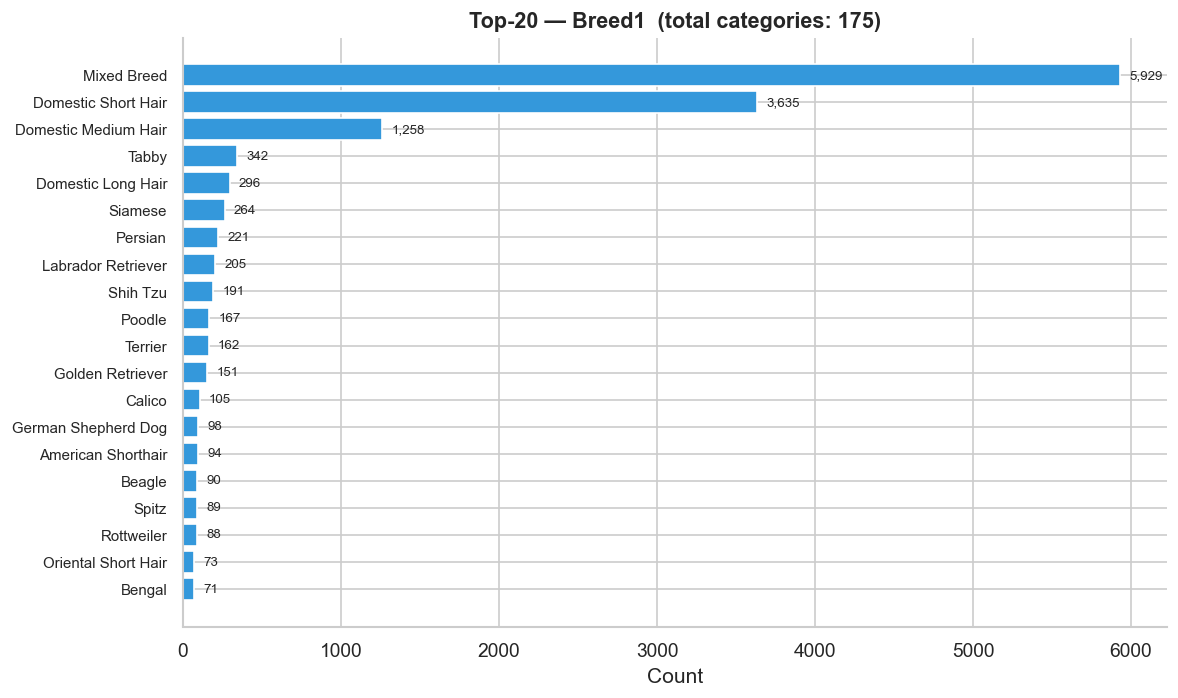

Breed1: 8 / 175 categories cover 80% of data


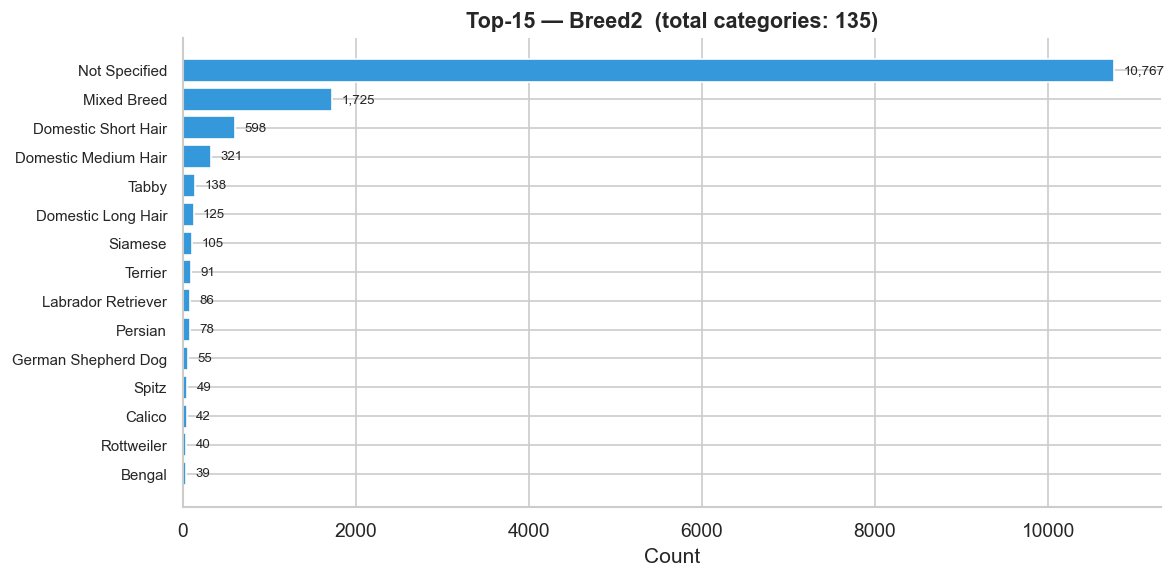

Breed2: 2 / 135 categories cover 80% of data


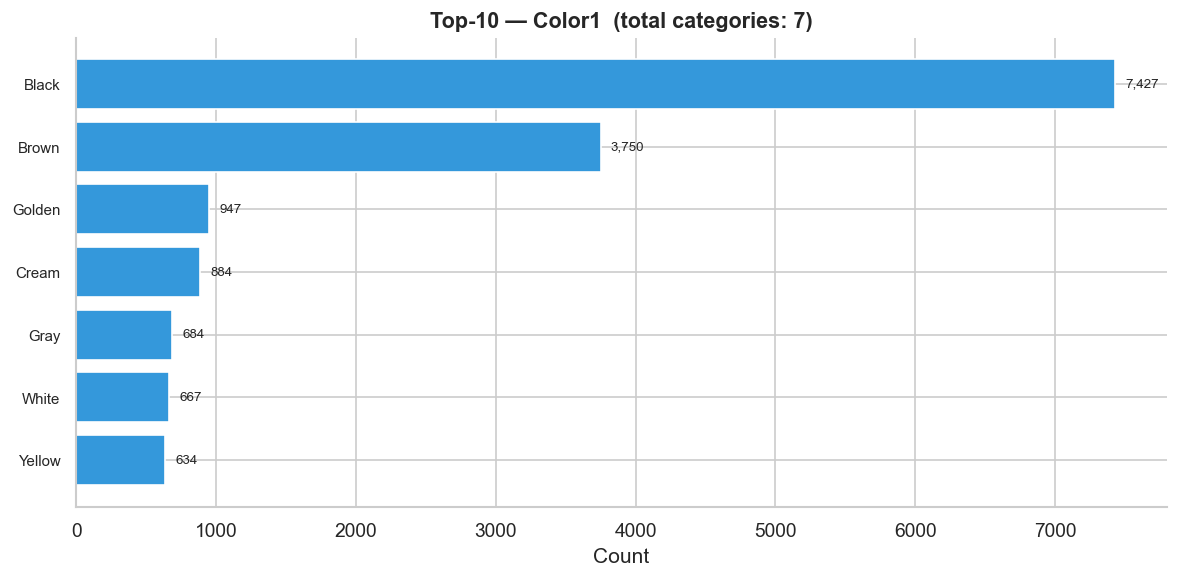

Color1: 3 / 7 categories cover 80% of data


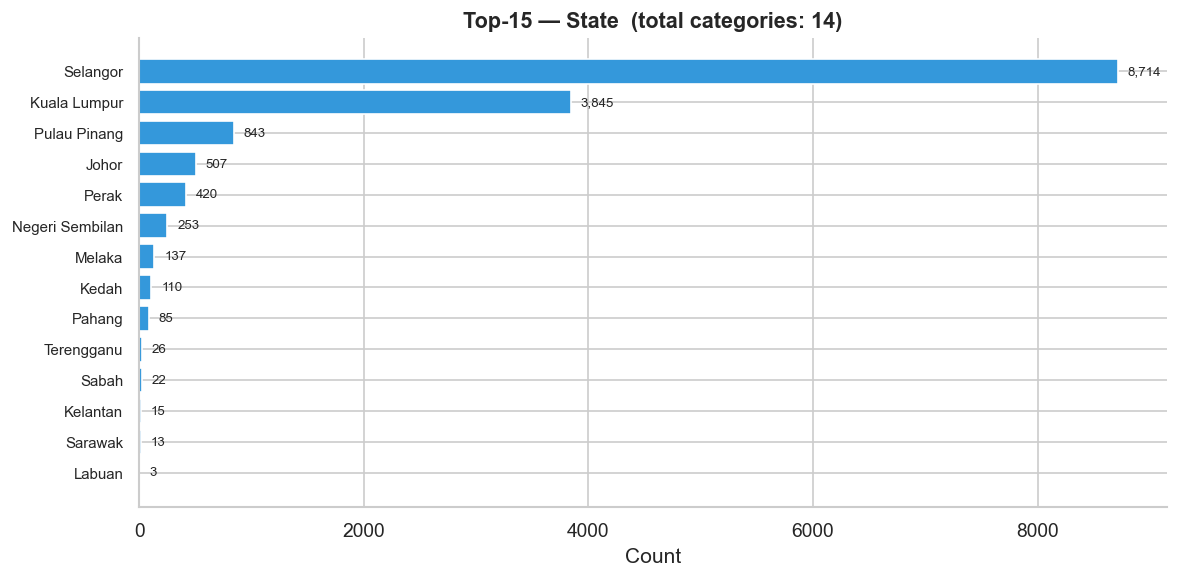

State: 2 / 14 categories cover 80% of data


In [ ]:
# ── Helper: Breed name mapping ──────────────────────────────────────
breed_map = dict(zip(ref_breeds["BreedID"], ref_breeds["BreedName"]))
breed_map[0] = "Not Specified"
color_map = dict(zip(ref_colors["ColorID"], ref_colors["ColorName"]))
color_map[0] = "Not Specified"
state_map = dict(zip(ref_states["StateID"], ref_states["StateName"]))

HIGH_CARD_COLS = {
    "Breed1": {"map": breed_map, "top_n": 20},
    "Breed2": {"map": breed_map, "top_n": 15},
    "Color1": {"map": color_map, "top_n": 10},
    "State":  {"map": state_map, "top_n": 15},
}

for col, params in HIGH_CARD_COLS.items():
    vc = train[col].value_counts()
    top = vc.head(params["top_n"])
    top.index = [f"{params['map'].get(i, i)}" for i in top.index]

    # Long-tail analysis: how many categories cover 80% of data
    cumsum = vc.cumsum() / vc.sum()
    n_80 = int((cumsum <= 0.80).sum()) + 1
    total_cats = len(vc)

    fig, ax = plt.subplots(figsize=(10, max(5, params["top_n"] * 0.3)))
    ax.barh(range(len(top)), top.values, color="#3498db", edgecolor="white")
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top.index, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Count")
    ax.set_title(f"Top-{params['top_n']} — {col}  (total categories: {total_cats})",
                 fontsize=13, fontweight="bold")

    # Annotate counts
    for i, v in enumerate(top.values):
        ax.text(v + vc.max() * 0.01, i, f"{v:,}", va="center", fontsize=8)

    sns.despine(ax=ax)
    fig.tight_layout()
    saved_figures.append(save_figure(fig, f"high_card_{col.lower()}"))
    plt.show()

    print(f"{col}: {n_80} / {total_cats} categories cover 80% of data")

---
## 7. Bivariate Analysis — Numeric vs. `AdoptionSpeed`

Distribution of each numeric feature grouped by target class.

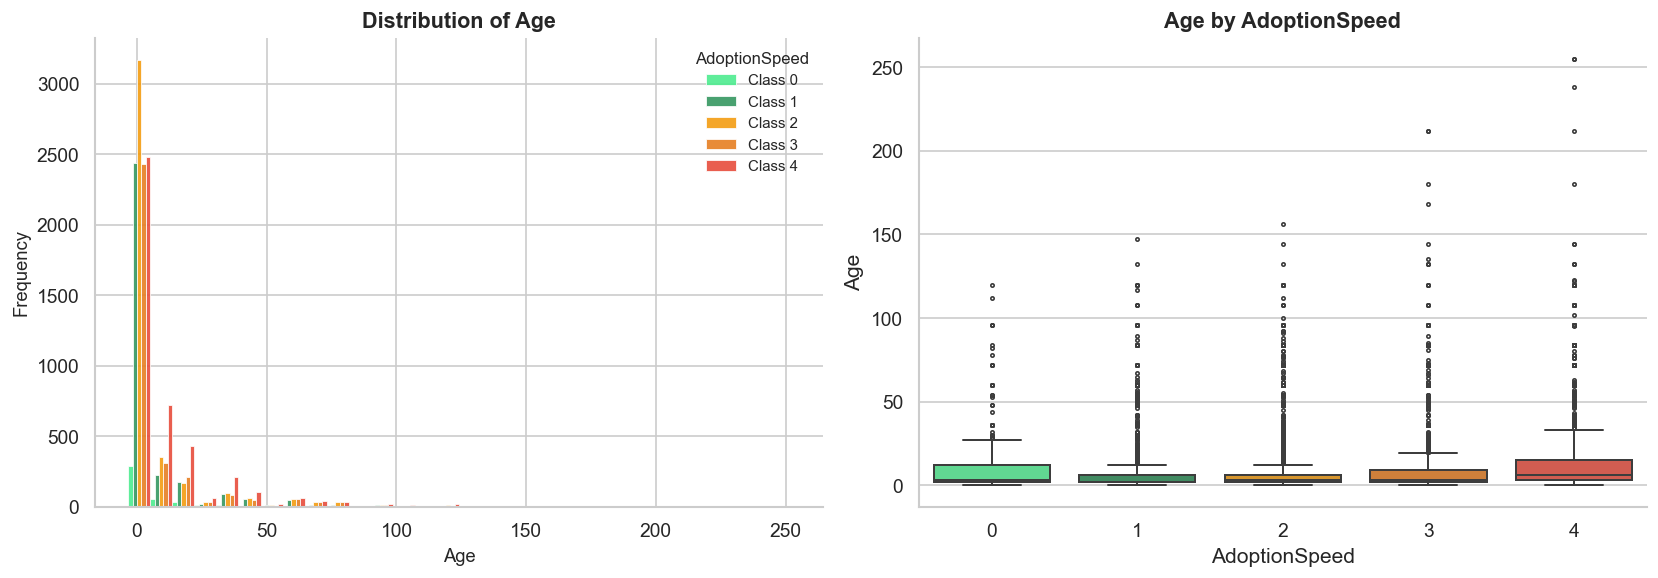

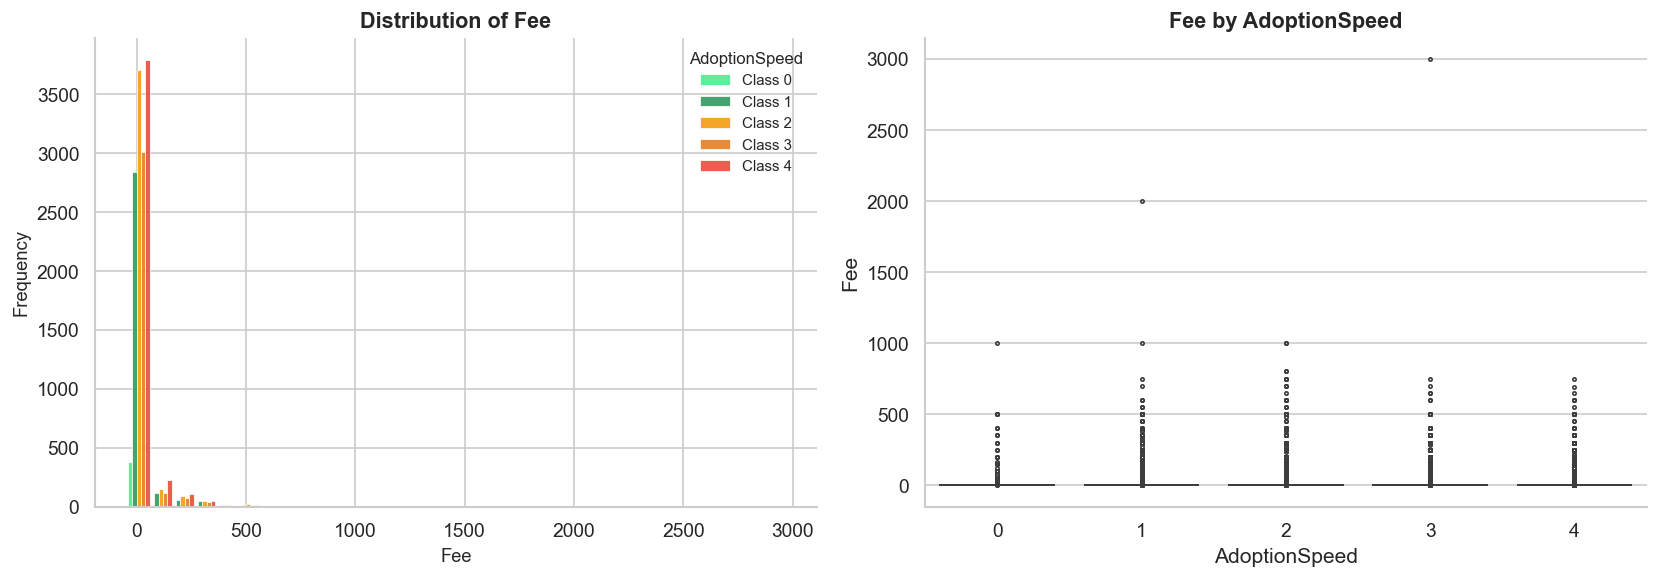

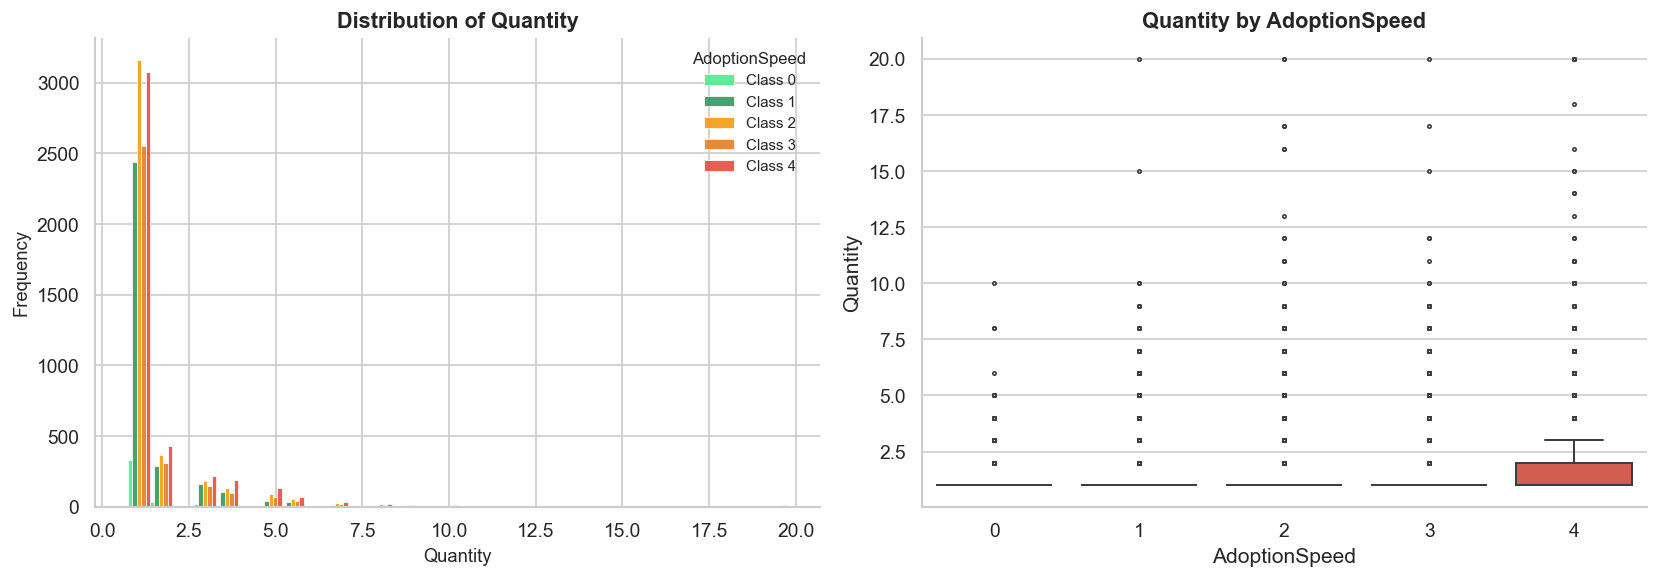

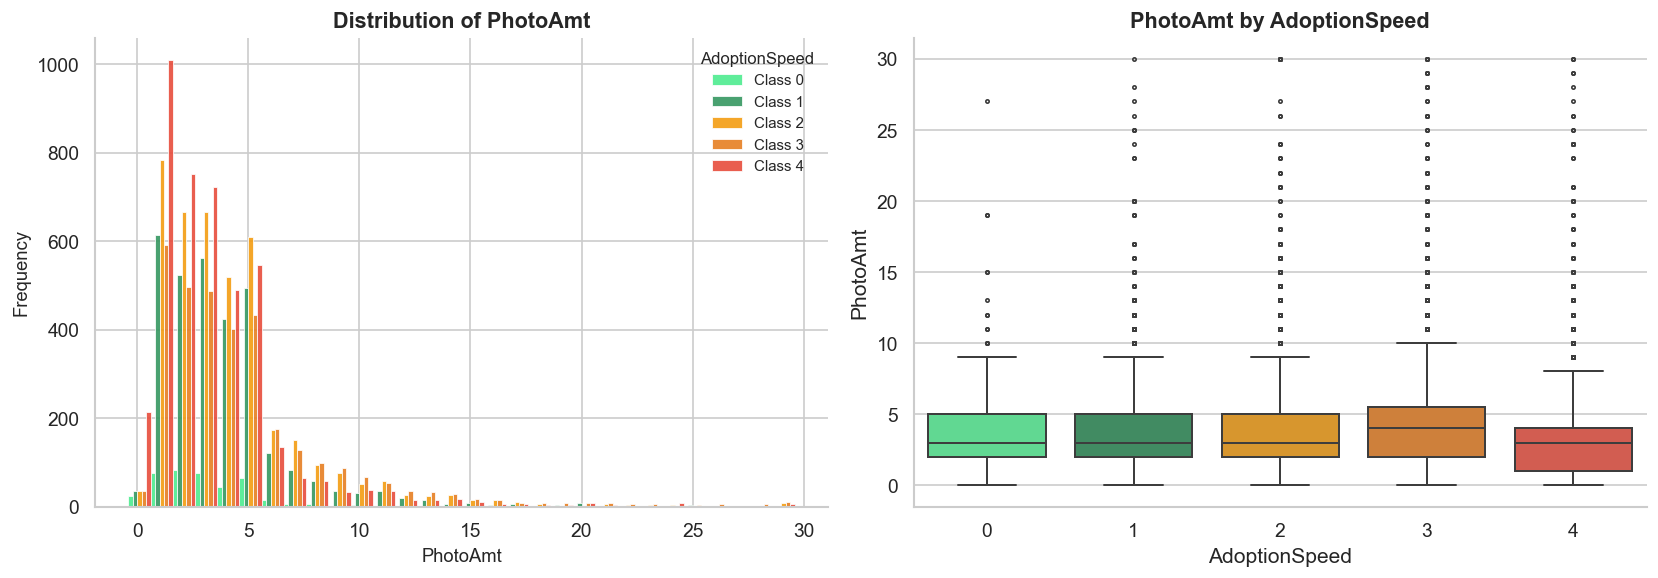

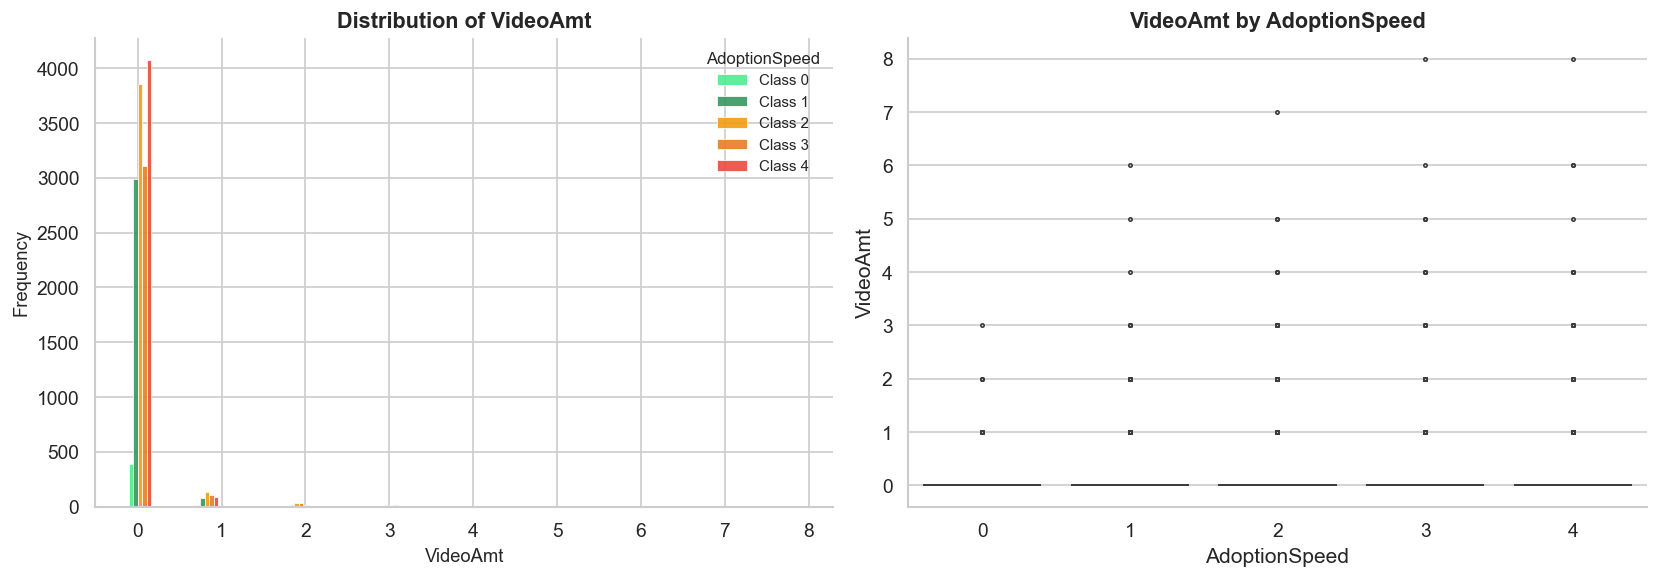

In [ ]:
# ── Grouped statistics by AdoptionSpeed ─────────────────────────────
grouped_stats = train.groupby("AdoptionSpeed")[NUMERIC_COLS].agg(["mean", "median"]).round(2)
display(grouped_stats.style.set_caption("Numeric Features by AdoptionSpeed Class"))

# ── Box plots per class ────────────────────────────────────────────
for col in NUMERIC_COLS:
    fig = plot_numeric_distribution(train, col, target_col="AdoptionSpeed")
    saved_figures.append(save_figure(fig, f"bivariate_{col.lower()}_vs_target"))
    plt.show()

---
## 8. Bivariate Analysis — Categorical vs. `AdoptionSpeed`

Proportional distribution of `AdoptionSpeed` per category.

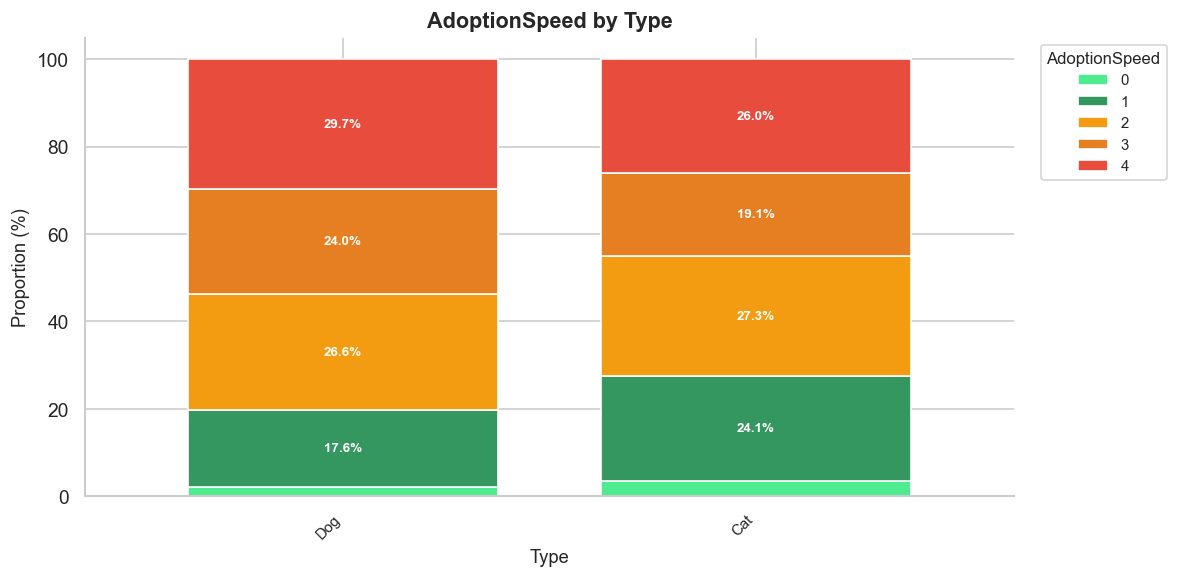

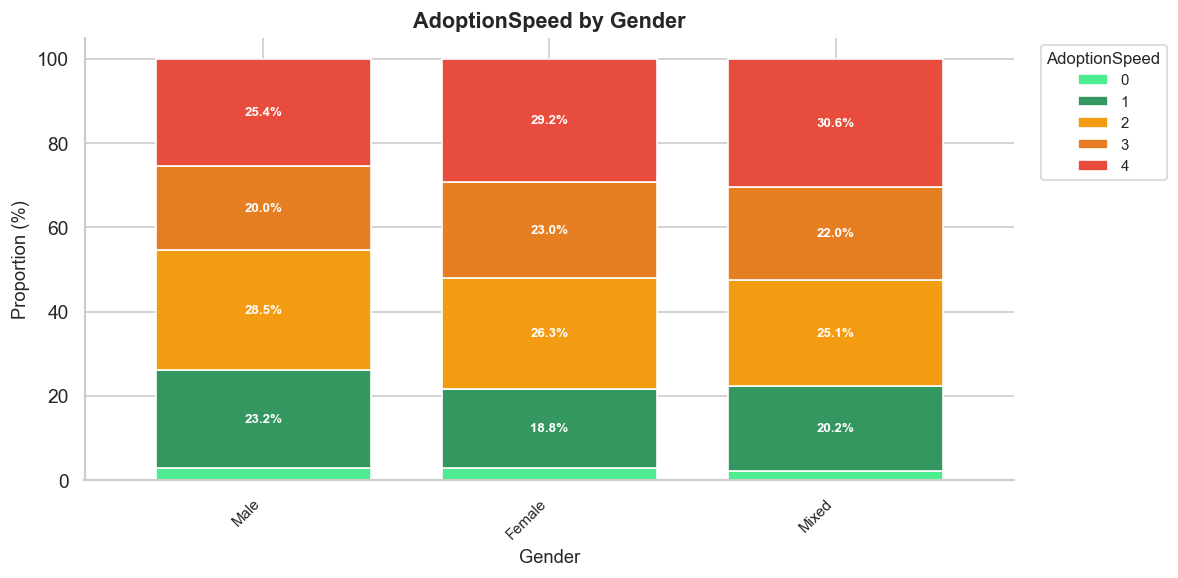

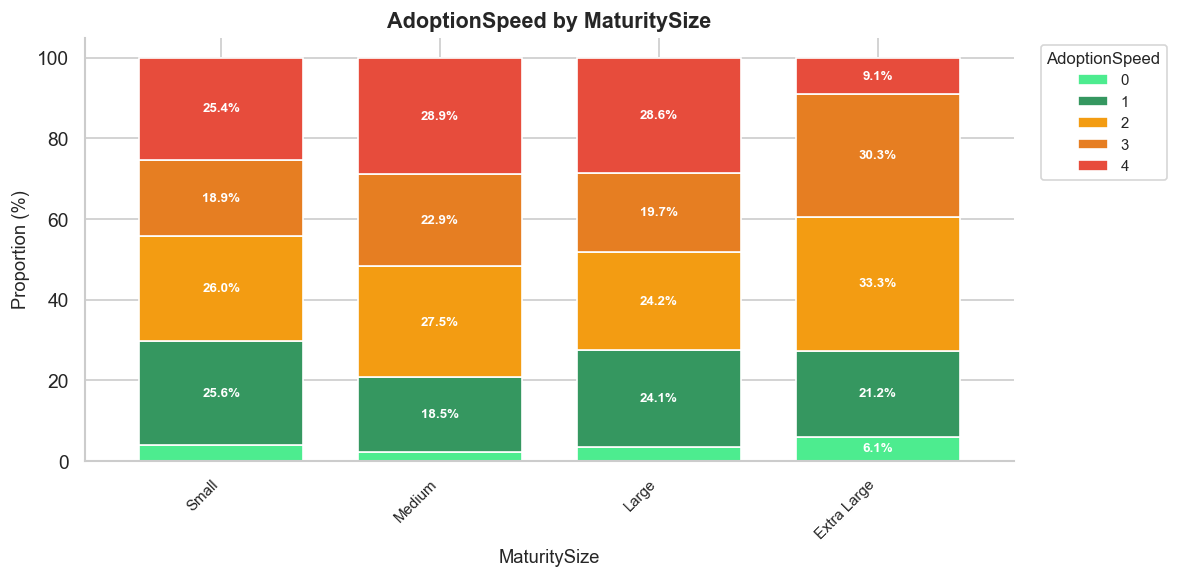

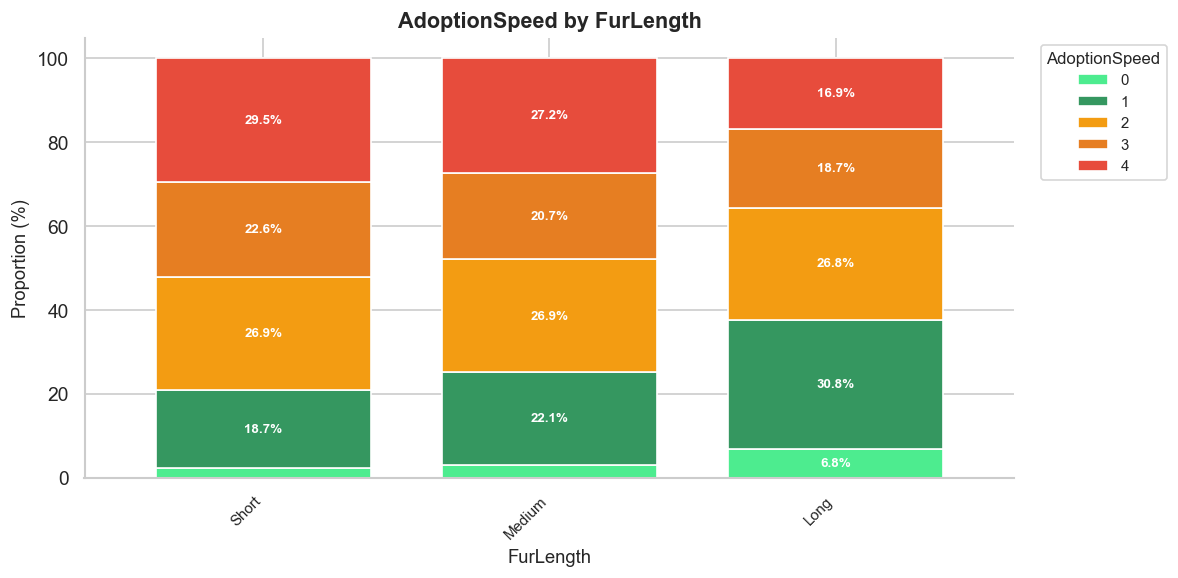

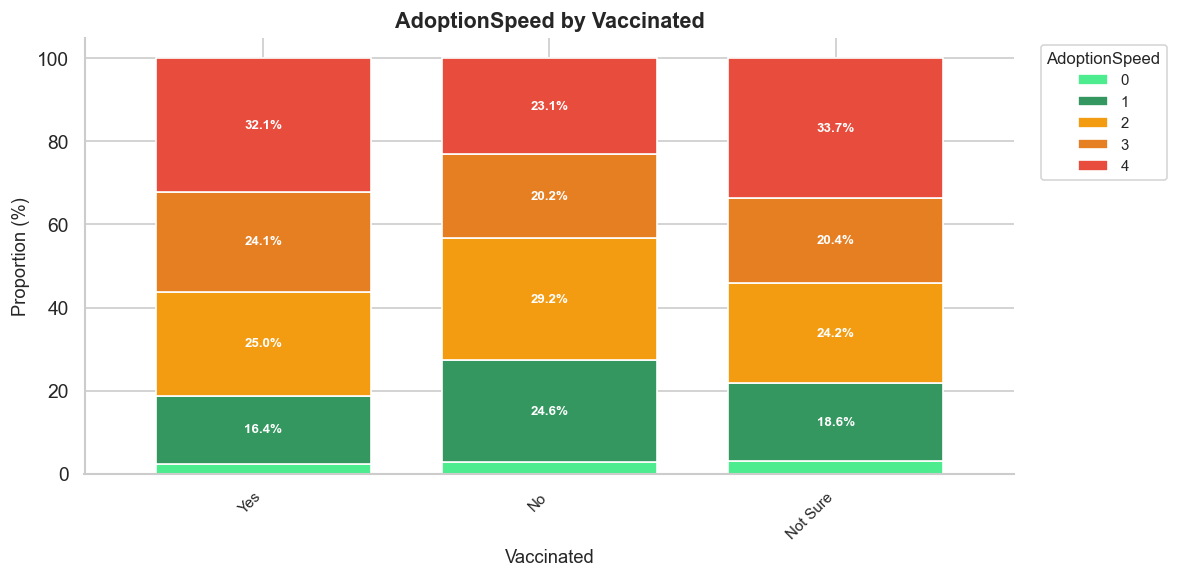

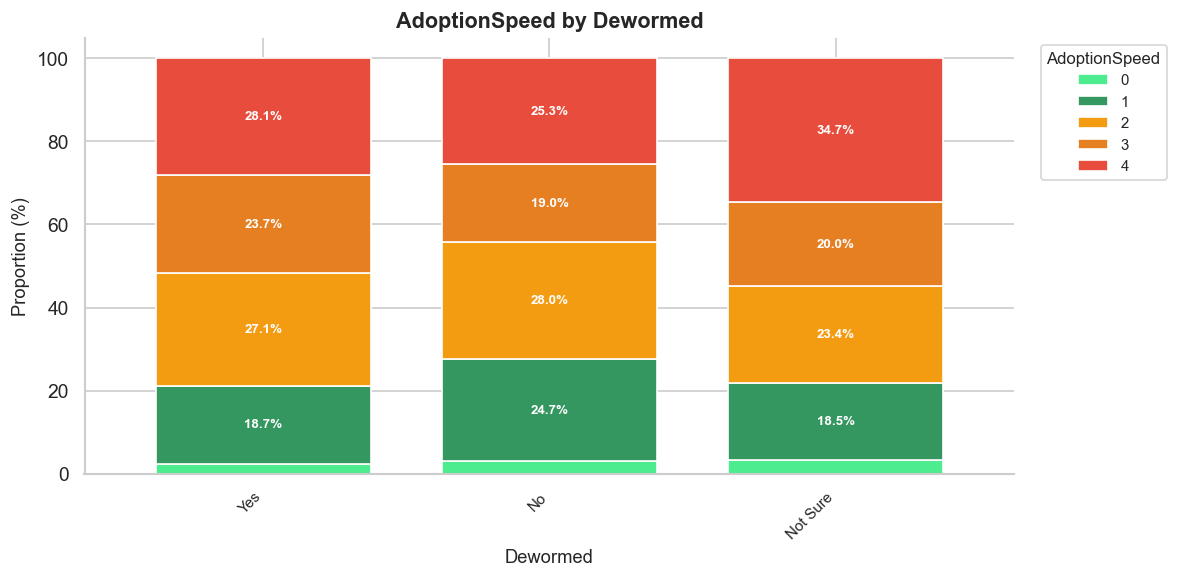

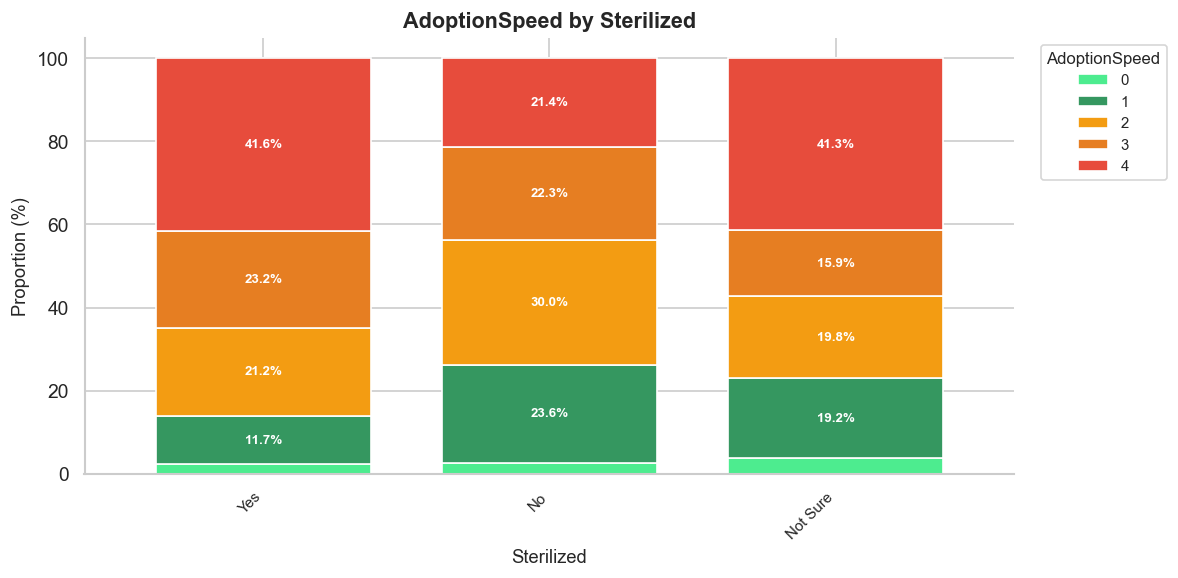

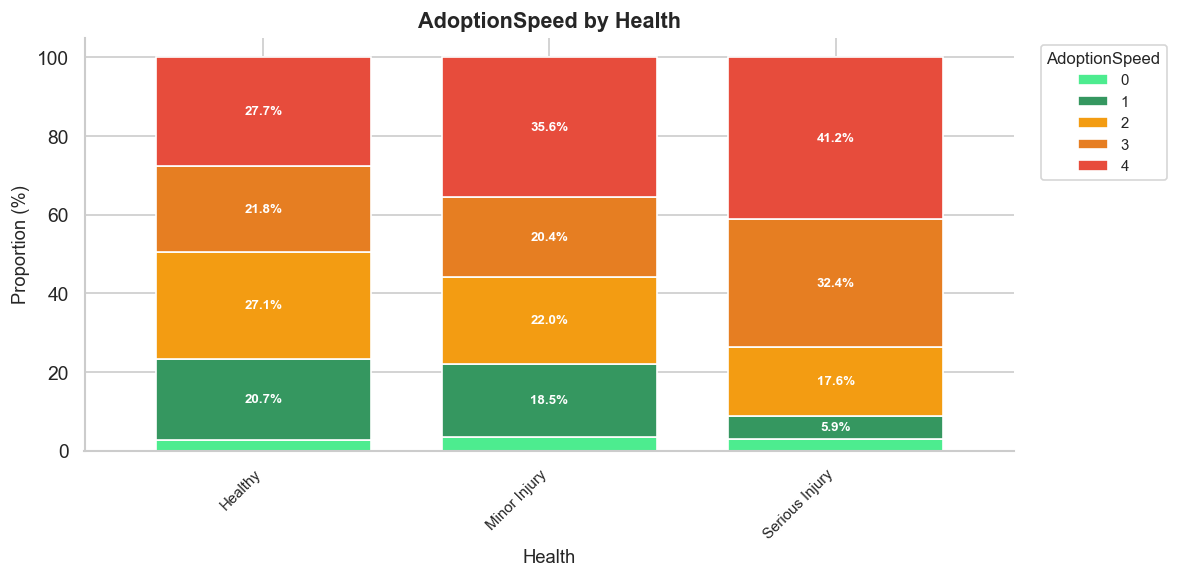

In [11]:
# ── Stacked bar charts: categorical features vs. AdoptionSpeed ──────
for col in CATEGORICAL_COLS:
    fig = plot_categorical_distribution(
        train, col,
        target_col="AdoptionSpeed",
        label_map=LABEL_MAPS.get(col),
    )
    saved_figures.append(save_figure(fig, f"bivariate_{col.lower()}_vs_target"))
    plt.show()

---
## 9. Correlation & Association Matrix

Pearson for numeric features, Cramér's V for categorical features.

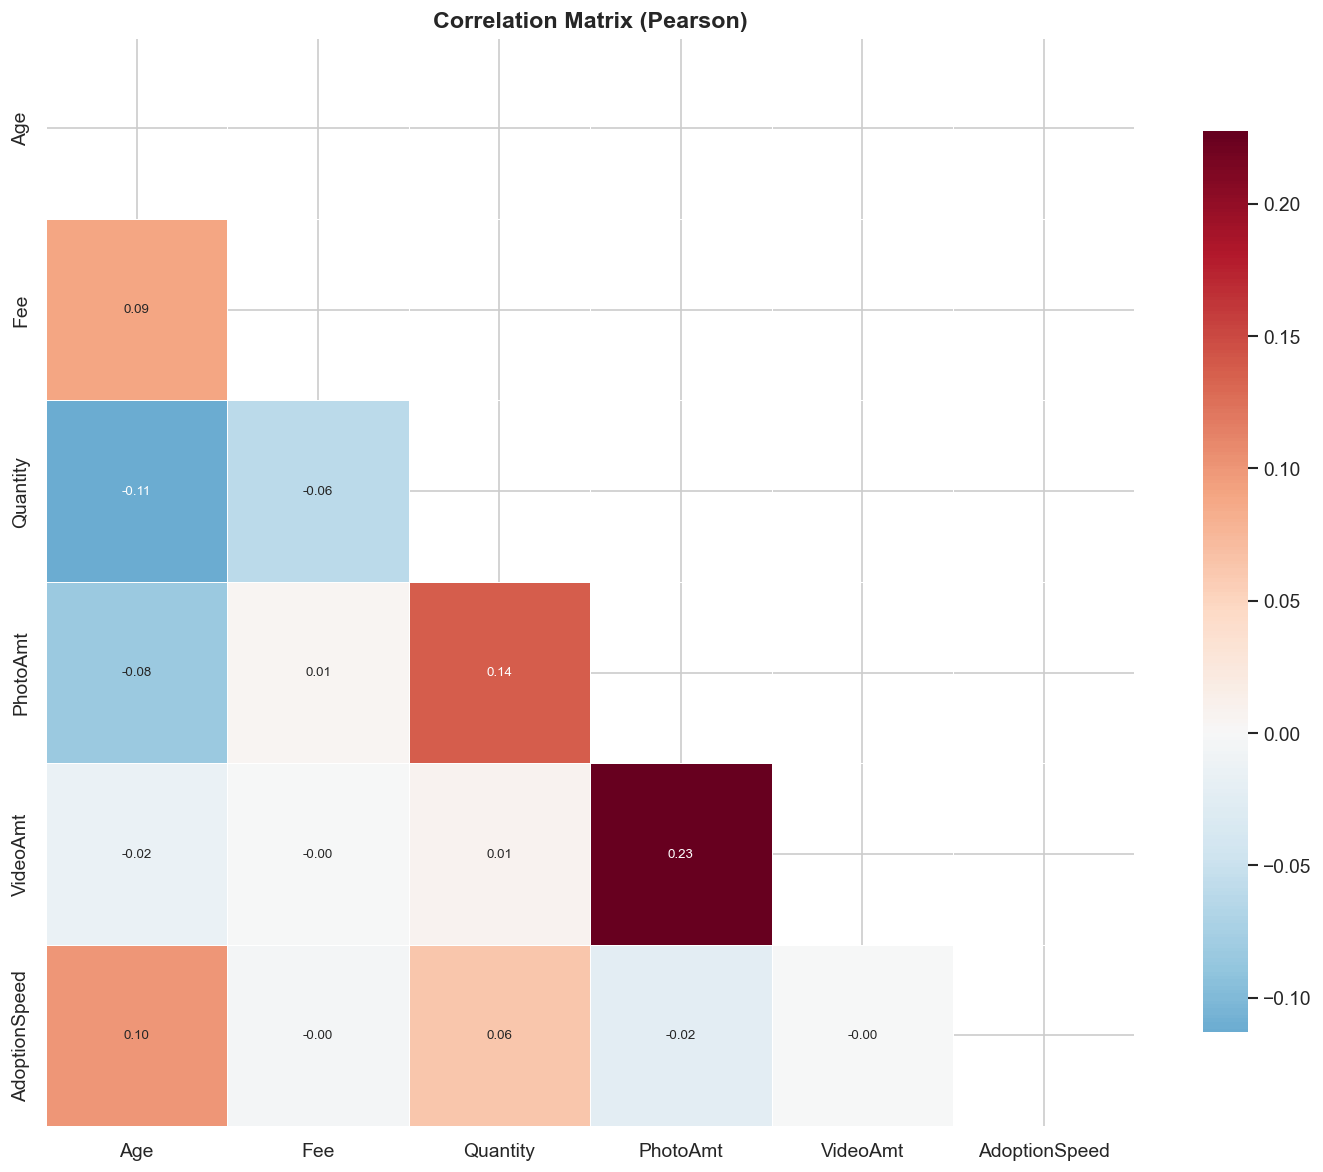

In [12]:
# ── Pearson correlation matrix (numeric features + target) ──────────
corr_cols = NUMERIC_COLS + ["AdoptionSpeed"]
fig = plot_correlation_matrix(train, corr_cols, method="pearson")
saved_figures.append(save_figure(fig, "correlation_pearson"))
plt.show()

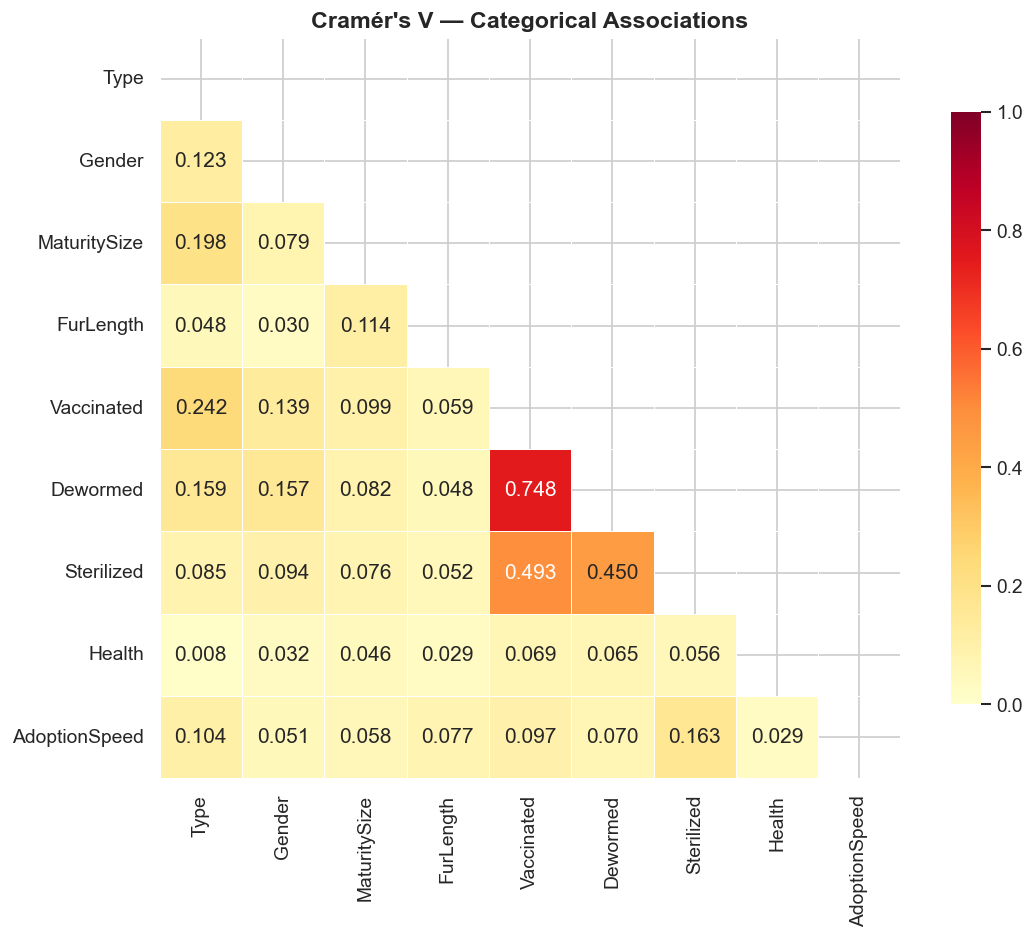

Notable associations (Cramér's V > 0.15):
  Type × MaturitySize: V = 0.198
  Type × Vaccinated: V = 0.242
  Type × Dewormed: V = 0.159
  Gender × Dewormed: V = 0.157
  Vaccinated × Dewormed: V = 0.748
  Vaccinated × Sterilized: V = 0.493
  Dewormed × Sterilized: V = 0.450
  Sterilized × AdoptionSpeed: V = 0.163


In [13]:
# ── Cramér's V matrix for categorical features ─────────────────────
cat_for_cramer = CATEGORICAL_COLS + ["AdoptionSpeed"]
cramers_matrix = compute_cramers_v_matrix(train, cat_for_cramer)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(cramers_matrix, dtype=bool))
sns.heatmap(
    cramers_matrix, mask=mask, annot=True, fmt=".3f",
    cmap="YlOrRd", square=True, linewidths=0.5, ax=ax,
    cbar_kws={"shrink": 0.8}, vmin=0, vmax=1,
)
ax.set_title("Cramér's V — Categorical Associations", fontsize=14, fontweight="bold")
fig.tight_layout()
saved_figures.append(save_figure(fig, "cramers_v_matrix"))
plt.show()

# ── Highlight strong associations ──────────────────────────────────
print("Notable associations (Cramér's V > 0.15):")
for i in range(len(cat_for_cramer)):
    for j in range(i + 1, len(cat_for_cramer)):
        v = cramers_matrix.iloc[i, j]
        if v > 0.15:
            print(f"  {cat_for_cramer[i]} × {cat_for_cramer[j]}: V = {v:.3f}")

---
## 10. Breed Analysis

Top breeds by volume and adoption speed. Purebred vs. mixed breed comparison.

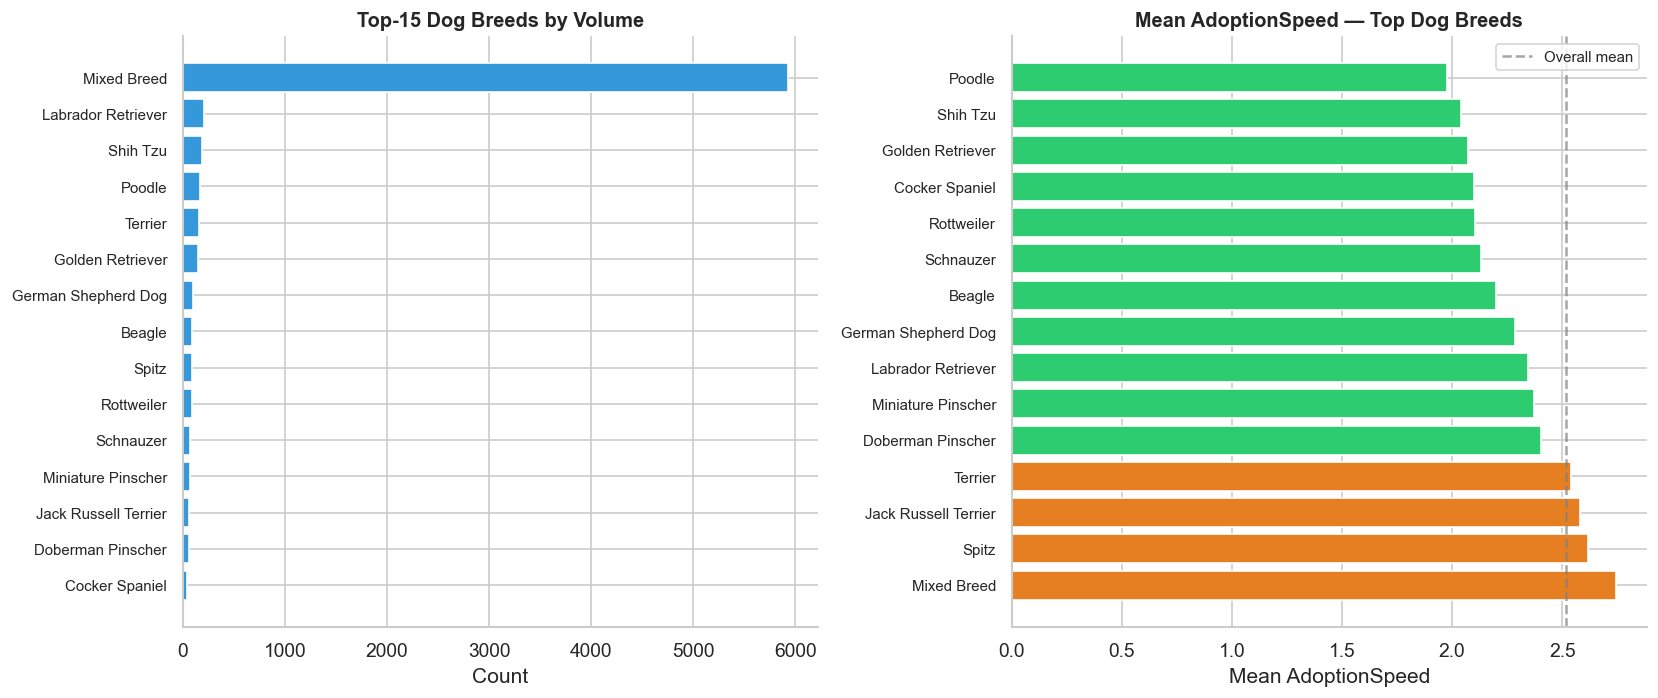

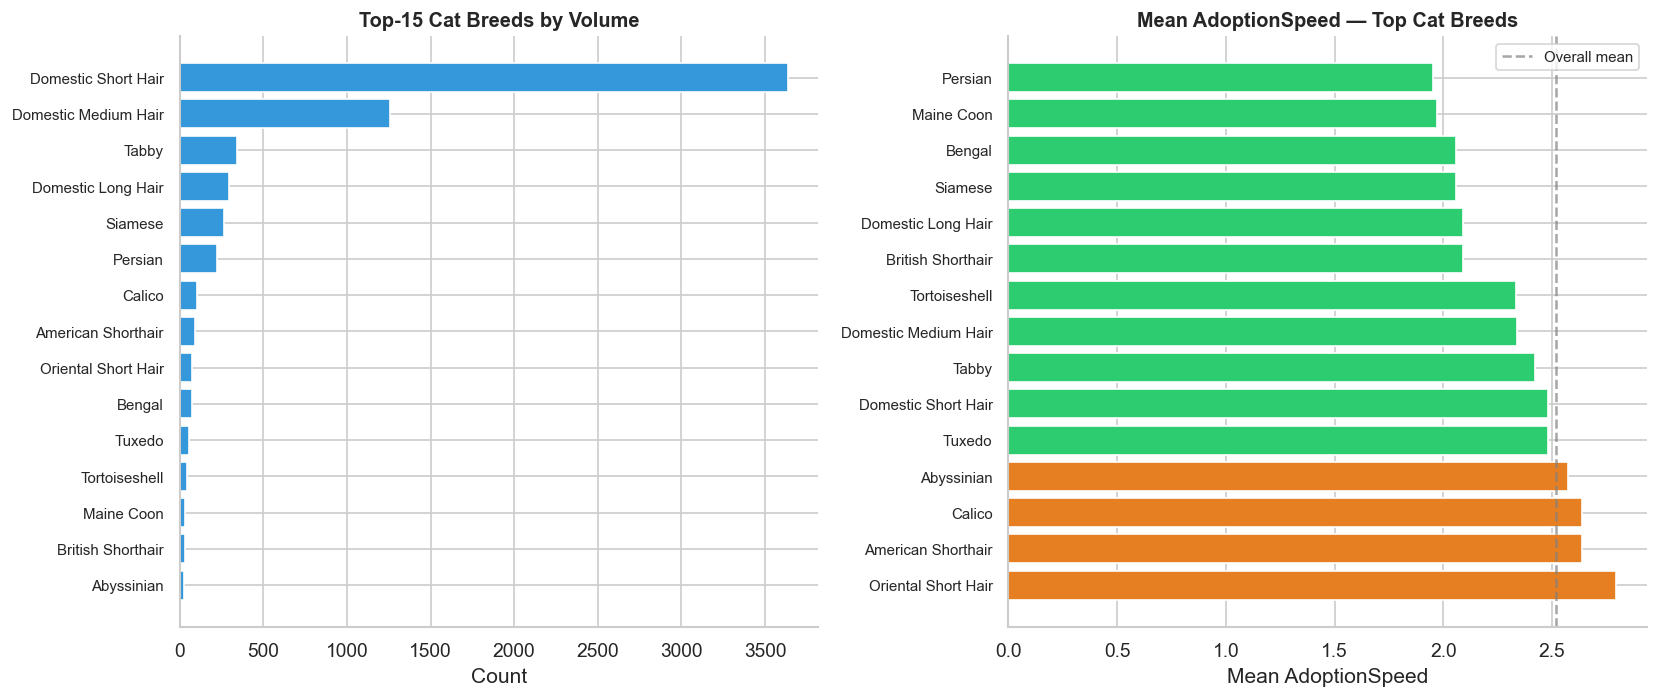

In [14]:
# ── Top-15 breeds by volume, split by Type ──────────────────────────
train["Breed1Name"] = train["Breed1"].map(breed_map).fillna("Unknown")
train["TypeLabel"] = train["Type"].map({1: "Dog", 2: "Cat"})

for animal_type in ["Dog", "Cat"]:
    subset = train[train["TypeLabel"] == animal_type]
    top_breeds = subset["Breed1Name"].value_counts().head(15)
    mean_speed = subset.groupby("Breed1Name")["AdoptionSpeed"].mean()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Volume
    axes[0].barh(range(len(top_breeds)), top_breeds.values, color="#3498db", edgecolor="white")
    axes[0].set_yticks(range(len(top_breeds)))
    axes[0].set_yticklabels(top_breeds.index, fontsize=9)
    axes[0].invert_yaxis()
    axes[0].set_xlabel("Count")
    axes[0].set_title(f"Top-15 {animal_type} Breeds by Volume", fontsize=12, fontweight="bold")

    # Mean AdoptionSpeed
    top_speed = mean_speed.loc[top_breeds.index].sort_values()
    colors = ["#2ecc71" if v < 2.5 else "#e67e22" if v < 3.0 else "#e74c3c" for v in top_speed.values]
    axes[1].barh(range(len(top_speed)), top_speed.values, color=colors, edgecolor="white")
    axes[1].set_yticks(range(len(top_speed)))
    axes[1].set_yticklabels(top_speed.index, fontsize=9)
    axes[1].invert_yaxis()
    axes[1].set_xlabel("Mean AdoptionSpeed")
    axes[1].set_title(f"Mean AdoptionSpeed — Top {animal_type} Breeds", fontsize=12, fontweight="bold")
    axes[1].axvline(x=train["AdoptionSpeed"].mean(), color="gray", linestyle="--", alpha=0.7, label="Overall mean")
    axes[1].legend(fontsize=9)

    sns.despine()
    fig.tight_layout()
    saved_figures.append(save_figure(fig, f"breed_analysis_{animal_type.lower()}"))
    plt.show()

Purebred (Breed2=0): 10,767  (71.8%)
Mixed (Breed2≠0):    4,226  (28.2%)


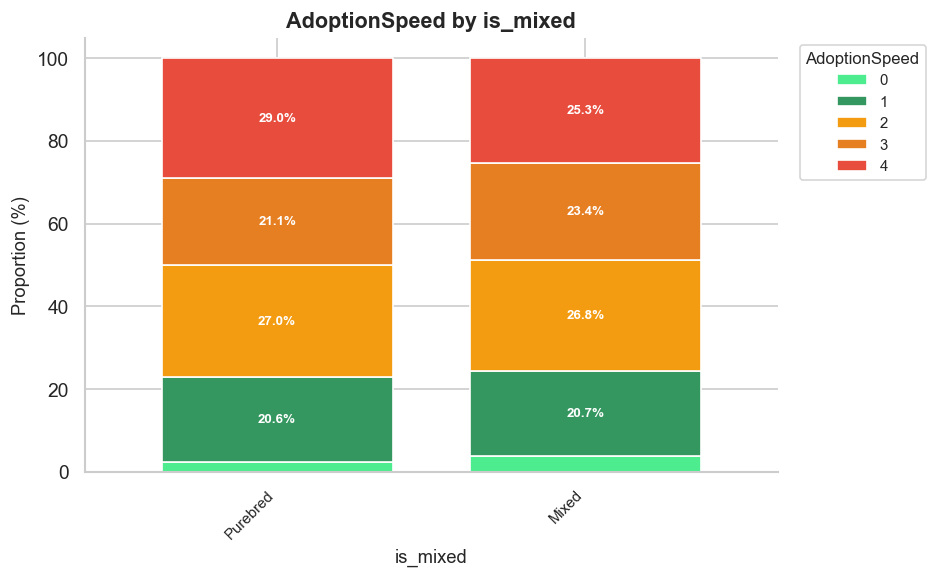

In [15]:
# ── Mixed breed feature ─────────────────────────────────────────────
train["is_mixed"] = (train["Breed2"] != 0).astype(int)

mixed_counts = train["is_mixed"].value_counts()
print(f"Purebred (Breed2=0): {mixed_counts.get(0, 0):,}  ({mixed_counts.get(0, 0)/len(train)*100:.1f}%)")
print(f"Mixed (Breed2≠0):    {mixed_counts.get(1, 0):,}  ({mixed_counts.get(1, 0)/len(train)*100:.1f}%)")

# ── Use your reusable function ──────────────────────────────────────
fig = plot_categorical_distribution(
    train,
    col="is_mixed",
    target_col="AdoptionSpeed",
    figsize=(8, 5),
    label_map={0: "Purebred", 1: "Mixed"},
)

saved_figures.append(save_figure(fig, "breed_mixed_vs_purebred"))
plt.show()

---
## 11. Geographic Analysis — `State`

Listing volume and adoption speed by Malaysian state.

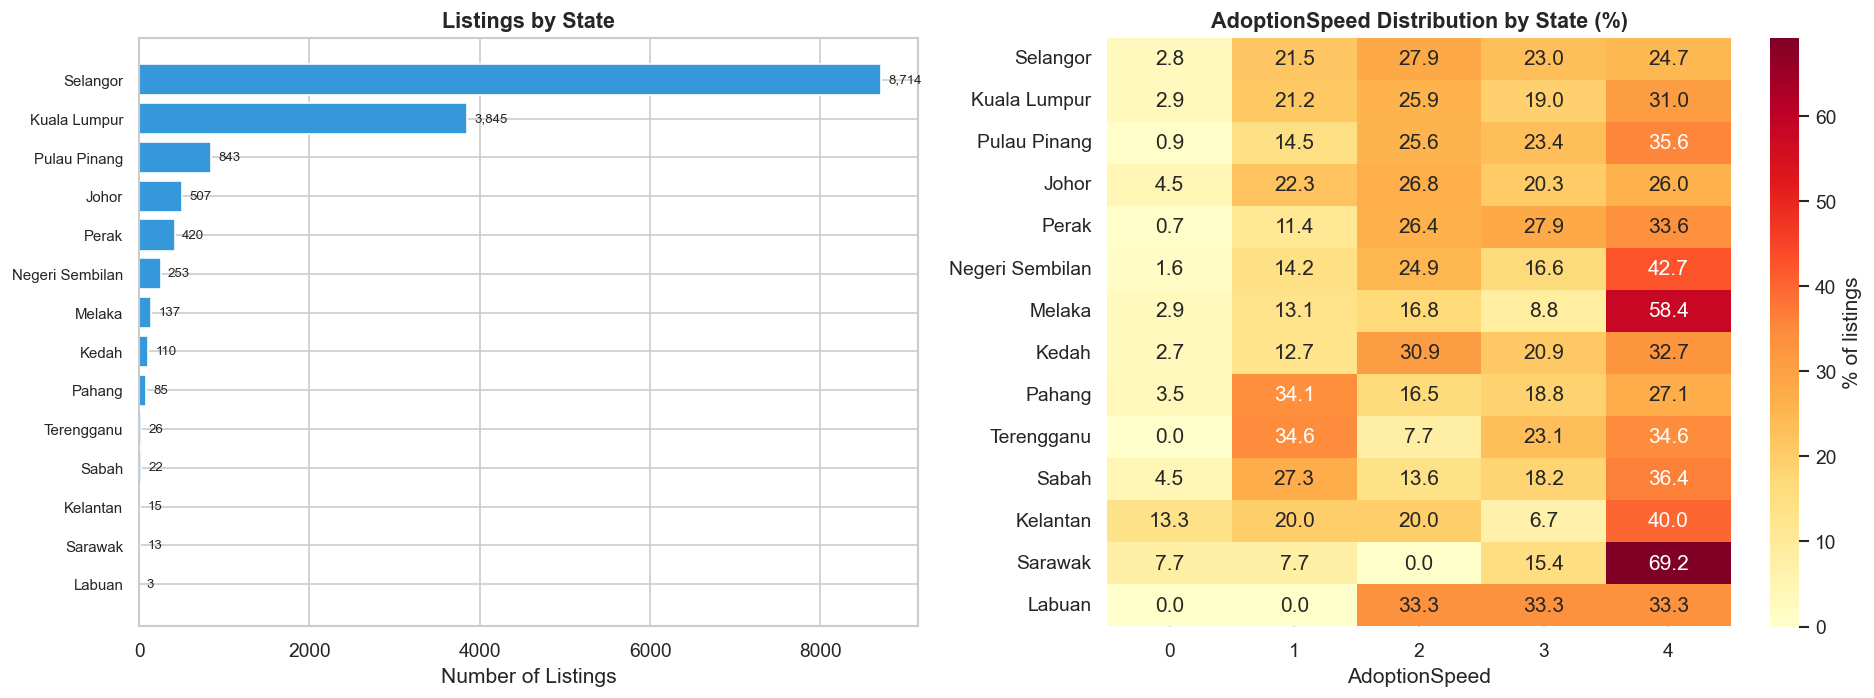

,mean_speed,n_listings
StateName,,
Pahang,2.32,85
Kelantan,2.40,15
Johor,2.41,507
Selangor,2.45,"8,714"
Kuala Lumpur,2.54,"3,845"
Sabah,2.55,22
Terengganu,2.58,26
Kedah,2.68,110
Pulau Pinang,2.78,843


In [16]:
# ── State label mapping ─────────────────────────────────────────────
train["StateName"] = train["State"].map(state_map)

# ── Volume by state ────────────────────────────────────────────────
state_volume = train["StateName"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Volume
axes[0].barh(range(len(state_volume)), state_volume.values, color="#3498db", edgecolor="white")
axes[0].set_yticks(range(len(state_volume)))
axes[0].set_yticklabels(state_volume.index, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel("Number of Listings")
axes[0].set_title("Listings by State", fontsize=13, fontweight="bold")
for i, v in enumerate(state_volume.values):
    axes[0].text(v + state_volume.max() * 0.01, i, f"{v:,}", va="center", fontsize=8)

# ── AdoptionSpeed heatmap by state ─────────────────────────────────
ct_state = pd.crosstab(train["StateName"], train["AdoptionSpeed"], normalize="index") * 100
ct_state = ct_state.loc[state_volume.index]  # keep same order
sns.heatmap(ct_state, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[1],
            cbar_kws={"label": "% of listings"})
axes[1].set_title("AdoptionSpeed Distribution by State (%)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("")

fig.tight_layout()
saved_figures.append(save_figure(fig, "geographic_analysis"))
plt.show()

# ── Mean adoption speed by state ───────────────────────────────────
state_speed = train.groupby("StateName")["AdoptionSpeed"].agg(["mean", "count"]).sort_values("mean")
state_speed.columns = ["mean_speed", "n_listings"]
display(state_speed.style.format({"mean_speed": "{:.2f}", "n_listings": "{:,}"})
        .set_caption("Adoption Speed by State"))

---
## 12. Fee Analysis

Comparison between free listings (Fee=0) and paid listings (Fee>0).

Free: 12,663 (84.5%)
Paid: 2,330 (15.5%)


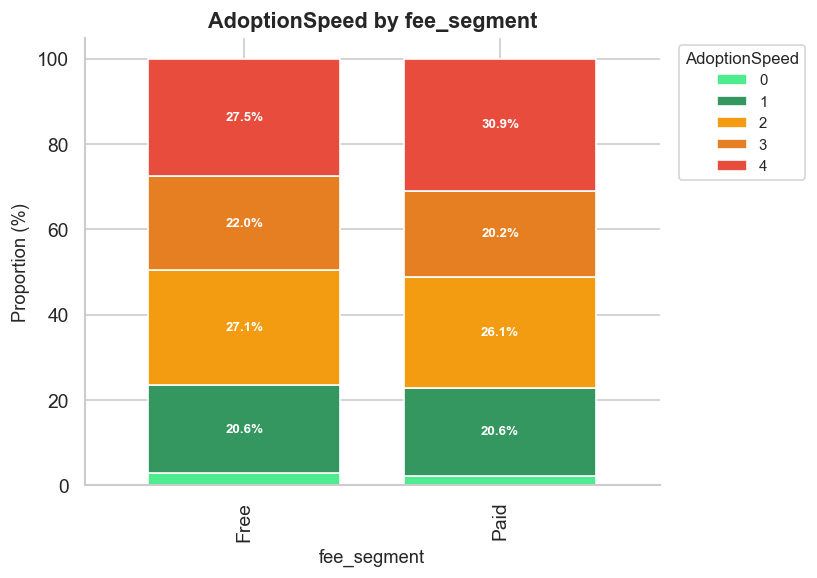

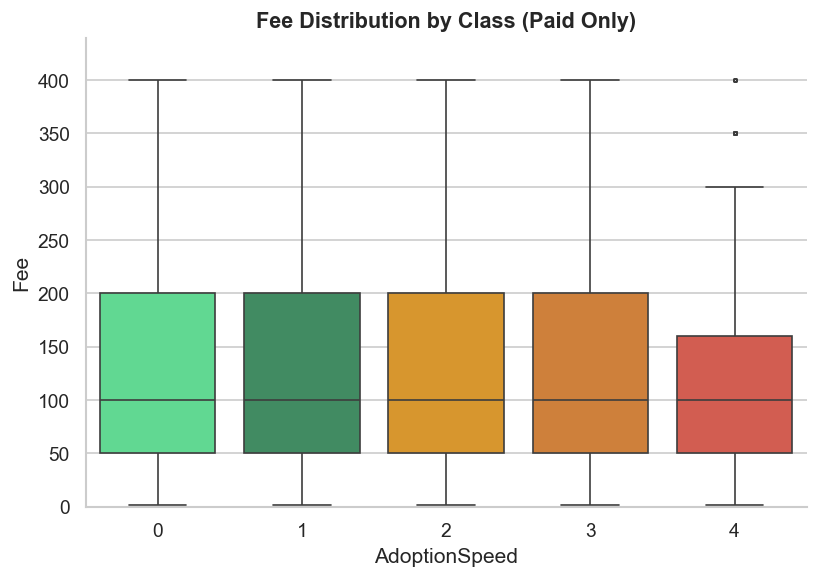


Fee percentiles (paid listings):


,count,mean,std,min,25%,50%,75%,90%,95%,max
Fee,2330,137,154,1,50,100,200,300,400,3000


In [17]:
# ── Free vs. Paid segmentation ──────────────────────────────────────
train["fee_segment"] = np.where(train["Fee"] == 0, "Free", "Paid")

seg_counts = train["fee_segment"].value_counts()
print(f"Free: {seg_counts['Free']:,} ({seg_counts['Free']/len(train)*100:.1f}%)")
print(f"Paid: {seg_counts['Paid']:,} ({seg_counts['Paid']/len(train)*100:.1f}%)")

# ── 1️⃣ Use your reusable categorical function ──────────────────────
fig1 = plot_categorical_distribution(
    train,
    col="fee_segment",
    target_col="AdoptionSpeed",
    figsize=(7, 5),
)

saved_figures.append(save_figure(fig1, "fee_adoption_speed"))
plt.show()


# ── 2️⃣ Fee distribution (Paid only) — keep custom boxplot ──────────
paid = train[train["Fee"] > 0]

fig2, ax = plt.subplots(figsize=(7, 5))

palette = [ADOPTION_SPEED_PALETTE[c] for c in sorted(paid["AdoptionSpeed"].unique())]

sns.boxplot(
    data=paid,
    x="AdoptionSpeed",
    y="Fee",
    palette=palette,
    ax=ax,
    fliersize=2,
)

ax.set_title("Fee Distribution by Class (Paid Only)", fontsize=13, fontweight="bold")
ax.set_ylim(0, paid["Fee"].quantile(0.95) * 1.1)

sns.despine(ax=ax)
fig2.tight_layout()

saved_figures.append(save_figure(fig2, "fee_distribution_paid_only"))
plt.show()


# ── Fee percentiles (paid only) ─────────────────────────────────────
print("\nFee percentiles (paid listings):")

display(
    paid["Fee"]
    .describe(percentiles=[.25, .50, .75, .90, .95])
    .to_frame()
    .T
    .style.format("{:.0f}")
    .set_caption("Fee Distribution — Paid Listings")
)

---
## 13. Rescuer Analysis

Statistics by `RescuerID`: listing volume, averages, and identification of high-volume rescuers.

Unique rescuers: 5,595
Listings per rescuer — mean: 2.7, median: 1, max: 459


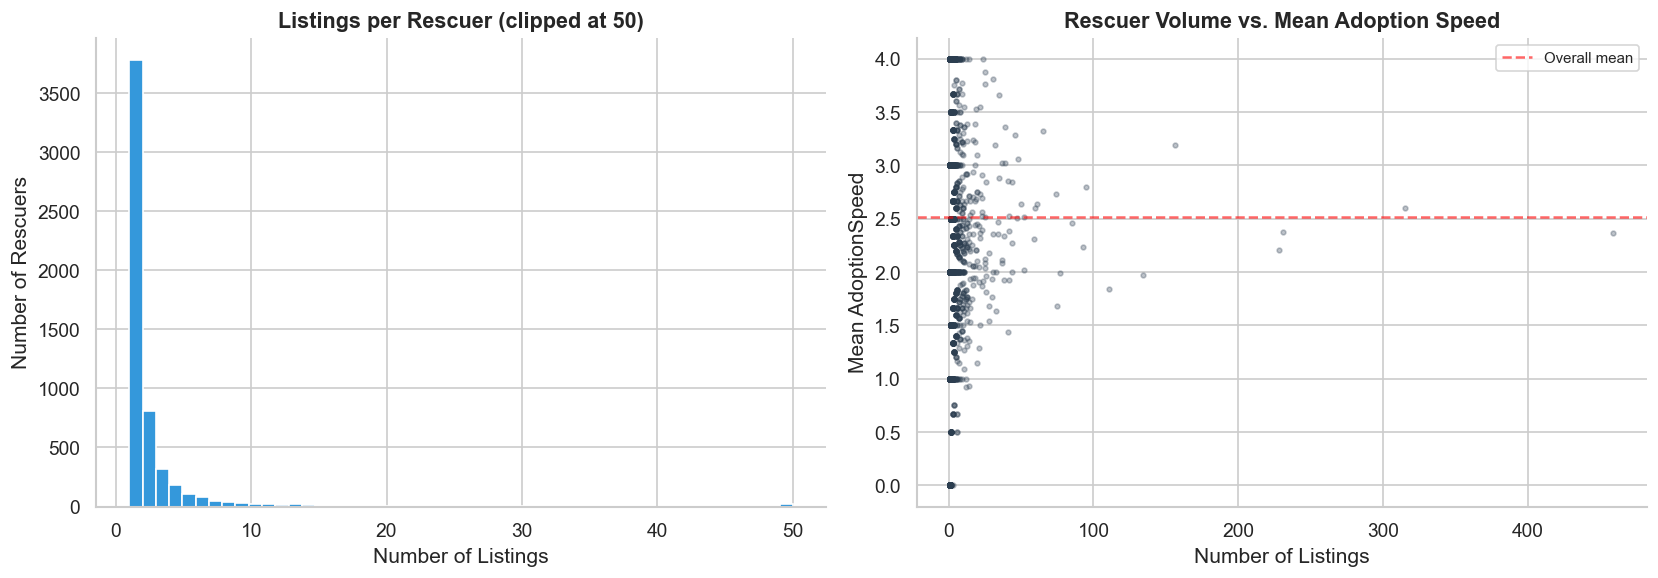

,RescuerID,n_listings,mean_speed,median_fee,mean_photos
5485,fa90fa5b1ee11c86938398b60abc32cb,459,2.37,0,3.6
3768,aa66486163b6cbc25ea62a34b11c9b91,315,2.60,0,5.5
4228,c00756f2bdd8fa88fc9f07a8309f7d5d,231,2.38,0,4.7
3996,b53c34474d9e24574bcec6a3d3306a0d,228,2.20,0,3.1
5204,ee2747ce26468ec44c7194e7d1d9dad9,156,3.19,0,4.7
3297,95481e953f8aed9ec3d16fc4509537e8,134,1.97,0,2.3
4040,b770bac0ca797cf1433c48a35d30c4cb,111,1.84,0,2.4
3547,a042471e0f43f2cf707104a1a138a7df,95,2.80,0,5.2
5548,fd970cc91d06d82eebf046340137b272,93,2.24,0,3.6
2799,7ed6d84e2e6879245e55447aee39c328,85,2.46,20,1.1


In [18]:
# ── Rescuer-level aggregation ───────────────────────────────────────
rescuer_stats = train.groupby("RescuerID").agg(
    n_listings=("PetID", "count"),
    mean_speed=("AdoptionSpeed", "mean"),
    median_fee=("Fee", "median"),
    mean_photos=("PhotoAmt", "mean"),
).reset_index()

print(f"Unique rescuers: {len(rescuer_stats):,}")
print(f"Listings per rescuer — mean: {rescuer_stats['n_listings'].mean():.1f}, "
      f"median: {rescuer_stats['n_listings'].median():.0f}, "
      f"max: {rescuer_stats['n_listings'].max()}")

# ── Distribution of listings per rescuer ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(rescuer_stats["n_listings"].clip(upper=50), bins=50,
             color="#3498db", edgecolor="white")
axes[0].set_xlabel("Number of Listings")
axes[0].set_ylabel("Number of Rescuers")
axes[0].set_title("Listings per Rescuer (clipped at 50)", fontsize=13, fontweight="bold")

# Mean speed vs. volume
axes[1].scatter(rescuer_stats["n_listings"], rescuer_stats["mean_speed"],
                alpha=0.3, s=8, color="#2c3e50")
axes[1].set_xlabel("Number of Listings")
axes[1].set_ylabel("Mean AdoptionSpeed")
axes[1].set_title("Rescuer Volume vs. Mean Adoption Speed", fontsize=13, fontweight="bold")
axes[1].axhline(y=train["AdoptionSpeed"].mean(), color="red", linestyle="--", alpha=0.6, label="Overall mean")
axes[1].legend(fontsize=9)

sns.despine()
fig.tight_layout()
saved_figures.append(save_figure(fig, "rescuer_analysis"))
plt.show()

# ── Top-10 rescuers by volume ──────────────────────────────────────
top_rescuers = rescuer_stats.nlargest(10, "n_listings")
display(top_rescuers.style.format({
    "mean_speed": "{:.2f}", "median_fee": "{:.0f}", "mean_photos": "{:.1f}"
}).set_caption("Top-10 Rescuers by Listing Volume"))

---
## 14. Name Analysis

Exploration of the `Name` column from a structured EDA perspective: missing values, placeholder patterns, length distribution, most common names, and signals related to `AdoptionSpeed`.

In [35]:
# ── Missing, empty & placeholder patterns ───────────────────────────
# NOTE: Cleaning of noisy names (placeholders, numeric-only, symbol-only)
# is handled upstream in Notebook 03 via handle_missing_names().
# The has_name flag already reflects the expanded cleaning.
# Here we detect the same patterns on the *original raw Name column*
# purely for EDA reporting — no mutation of the working DataFrame.

name_null = train["Name"].isna().sum()
name_total = len(train)

# Detect noisy patterns among non-null names (for reporting only)
name_filled = train["Name"].fillna("")
placeholder_re = r"(?i)^(no\s*name|unnamed|none|n/?a|unknown|\-+|\.+|\?+)$"
numeric_only_re = r"^\d+$"
symbol_heavy_re = r"^[^a-zA-Z0-9\s]+$"

is_placeholder = name_filled.str.match(placeholder_re)
is_numeric = name_filled.str.match(numeric_only_re)
is_symbol = name_filled.str.match(symbol_heavy_re)
noisy_mask = is_placeholder | is_numeric | is_symbol
noisy_count = int(noisy_mask.sum())

# Post-cleaning: noisy names were already set to NaN by NB03, so
# the counts above will be 0 if the cleaned data is used. We report
# the has_name flag distribution directly.
has_name_pct = train["has_name"].mean() * 100

# ── Summary table ──────────────────────────────────────────────────
name_quality = pd.DataFrame({
    "Category": ["Null / NaN (incl. cleaned noisy)", "Non-null placeholder (residual)",
                  "Numeric-only (residual)", "Symbol-only (residual)",
                  "Total without valid name (has_name=0)", "Valid names (has_name=1)"],
    "Count": [name_null, int(is_placeholder.sum()), int(is_numeric.sum()), int(is_symbol.sum()),
              int((train["has_name"] == 0).sum()), int((train["has_name"] == 1).sum())],
    "% of Total": [
        round(name_null / name_total * 100, 2),
        round(is_placeholder.sum() / name_total * 100, 2),
        round(is_numeric.sum() / name_total * 100, 2),
        round(is_symbol.sum() / name_total * 100, 2),
        round((train["has_name"] == 0).mean() * 100, 2),
        round(has_name_pct, 2),
    ],
})
display(name_quality.style.format({"% of Total": "{:.2f}%"}).set_caption("Name Column — Quality Breakdown"))

print(f"\n✅ {train['has_name'].sum():,} pets ({has_name_pct:.1f}%) have a valid name (has_name=1).")
print(f"   (Noisy names were cleaned to NaN in Notebook 03)")

,Category,Count,% of Total
0,Null / NaN (incl. cleaned noisy),1420,9.47%
1,Non-null placeholder (residual),0,0.00%
2,Numeric-only (residual),0,0.00%
3,Symbol-only (residual),0,0.00%
4,Total without valid name (has_name=0),1420,9.47%
5,Valid names (has_name=1),13573,90.53%



✅ 13,573 pets (90.5%) have a valid name (has_name=1).
   (Noisy names were cleaned to NaN in Notebook 03)


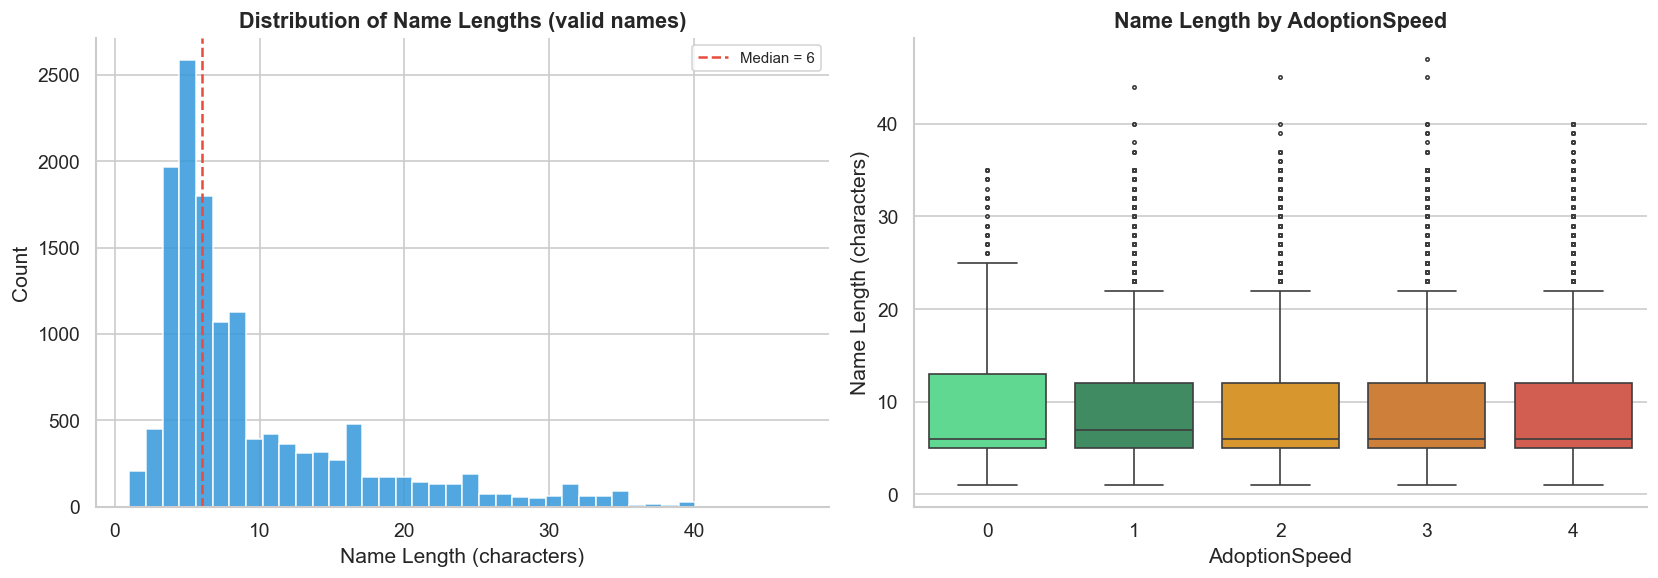

Valid name lengths — mean: 9.5, median: 6, max: 47, std: 7.3


In [36]:
# ── Name length distribution ─────────────────────────────────────────
valid_names = train.loc[train["has_name"] == 1, "Name"].str.strip()
train["name_length"] = train["Name"].fillna("").str.strip().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of name lengths (valid names only)
valid_lengths = valid_names.str.len()
axes[0].hist(valid_lengths, bins=40, color="#3498db", edgecolor="white", alpha=0.85)
axes[0].axvline(valid_lengths.median(), color="#e74c3c", linestyle="--", label=f"Median = {valid_lengths.median():.0f}")
axes[0].set_xlabel("Name Length (characters)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Name Lengths (valid names)", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=9)

# Name length vs AdoptionSpeed (box plot)
palette = [ADOPTION_SPEED_PALETTE[c] for c in range(5)]
sns.boxplot(data=train[train["has_name"] == 1], x="AdoptionSpeed", y="name_length",
            palette=palette, ax=axes[1], fliersize=2)
axes[1].set_title("Name Length by AdoptionSpeed", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Name Length (characters)")

sns.despine()
fig.tight_layout()
saved_figures.append(save_figure(fig, "name_length_distribution"))
plt.show()

print(f"Valid name lengths — mean: {valid_lengths.mean():.1f}, median: {valid_lengths.median():.0f}, "
      f"max: {valid_lengths.max()}, std: {valid_lengths.std():.1f}")

Unique valid names: 9,001
Names appearing more than once: 1,243 (13.8%)


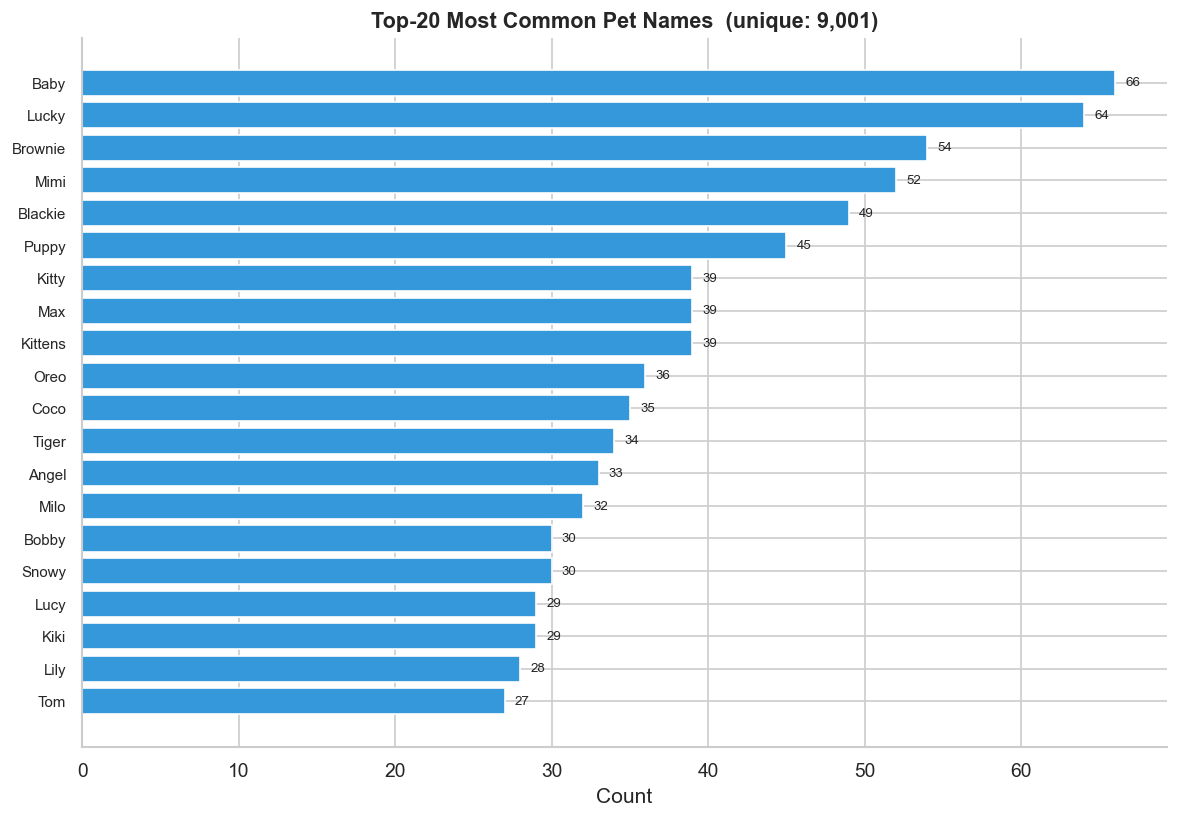

,n_names
appearances,
1,7758
2,597
3,211
4,120
5,62
6,41
7,46
8,28
9,27


In [37]:
# ── Most common names & repeated names ──────────────────────────────
name_freq = valid_names.value_counts()
n_unique = len(name_freq)
n_repeated = (name_freq > 1).sum()

print(f"Unique valid names: {n_unique:,}")
print(f"Names appearing more than once: {n_repeated:,} ({n_repeated / n_unique * 100:.1f}%)")

# Top-20 most common names
top_names = name_freq.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(len(top_names)), top_names.values, color="#3498db", edgecolor="white")
ax.set_yticks(range(len(top_names)))
ax.set_yticklabels(top_names.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Count")
ax.set_title(f"Top-20 Most Common Pet Names  (unique: {n_unique:,})", fontsize=13, fontweight="bold")
for i, v in enumerate(top_names.values):
    ax.text(v + top_names.max() * 0.01, i, f"{v:,}", va="center", fontsize=8)
sns.despine(ax=ax)
fig.tight_layout()
saved_figures.append(save_figure(fig, "name_top20"))
plt.show()

# Frequency distribution: how many names appear N times
freq_of_freq = name_freq.value_counts().sort_index().head(10)
display(pd.DataFrame({"appearances": freq_of_freq.index, "n_names": freq_of_freq.values})
        .set_index("appearances")
        .style.set_caption("Name Frequency Distribution — How many names appear N times"))

---
## 15. Feature Interaction Hypotheses

Exploratory analysis of interactions: Age × Type, Fee × State, Vaccinated × Health.

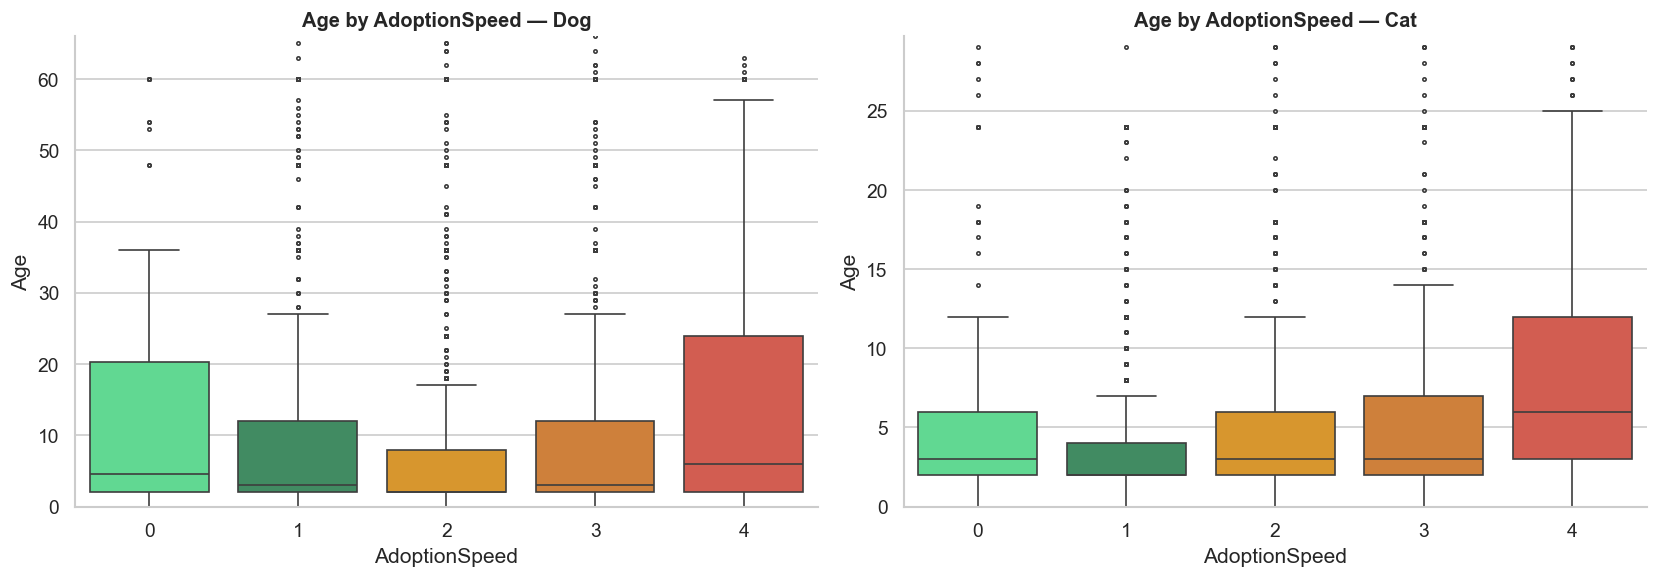

In [25]:
# ── Interaction 1: Age × Type ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (animal, label) in enumerate([(1, "Dog"), (2, "Cat")]):
    subset = train[train["Type"] == animal]
    palette = [ADOPTION_SPEED_PALETTE[c] for c in sorted(subset["AdoptionSpeed"].unique())]
    sns.boxplot(data=subset, x="AdoptionSpeed", y="Age", palette=palette,
                ax=axes[i], fliersize=2)
    axes[i].set_title(f"Age by AdoptionSpeed — {label}", fontsize=12, fontweight="bold")
    axes[i].set_ylim(0, subset["Age"].quantile(0.95) * 1.1)

sns.despine()
fig.tight_layout()
saved_figures.append(save_figure(fig, "interaction_age_type"))
plt.show()

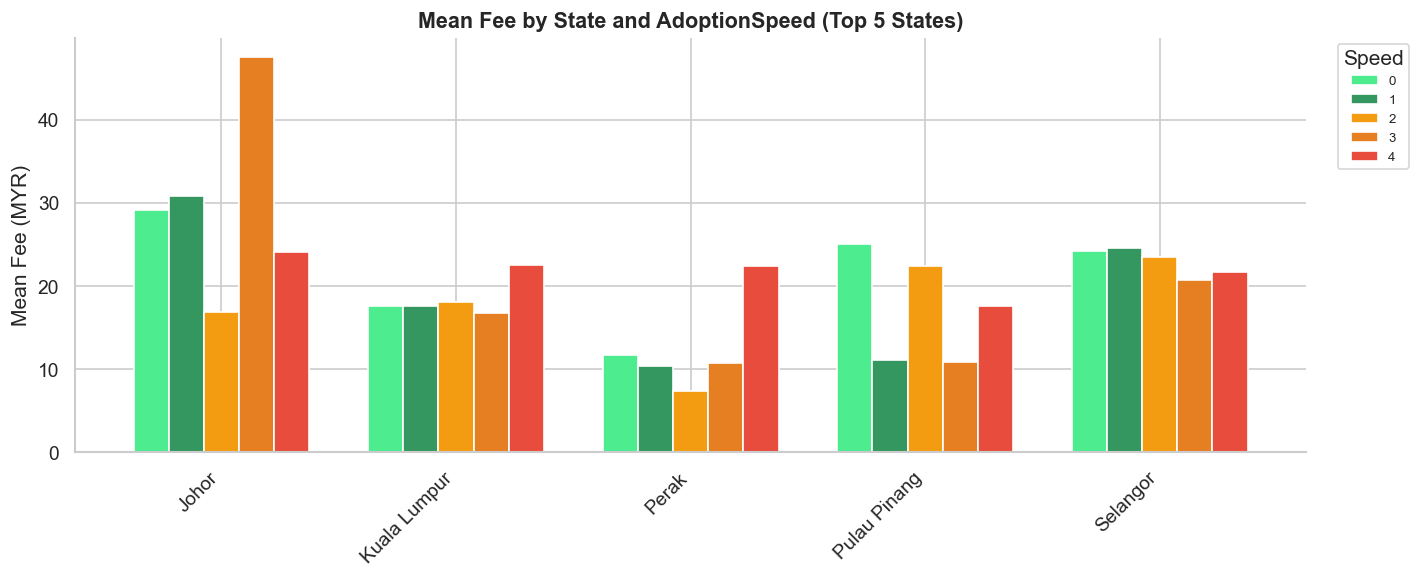

In [26]:
# ── Interaction 2: Fee × State (top 5 states) ──────────────────────
top5_states = train["StateName"].value_counts().head(5).index.tolist()
train_top_states = train[train["StateName"].isin(top5_states)]

fig, ax = plt.subplots(figsize=(12, 5))
mean_fee_state = train_top_states.groupby(["StateName", "AdoptionSpeed"])["Fee"].mean().unstack()
mean_fee_state.plot(kind="bar", ax=ax, edgecolor="white",
                    color=[ADOPTION_SPEED_PALETTE[c] for c in range(5)], width=0.75)
ax.set_title("Mean Fee by State and AdoptionSpeed (Top 5 States)", fontsize=13, fontweight="bold")
ax.set_ylabel("Mean Fee (MYR)")
ax.set_xlabel("")
ax.legend(title="Speed", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
sns.despine(ax=ax)
fig.tight_layout()
saved_figures.append(save_figure(fig, "interaction_fee_state"))
plt.show()

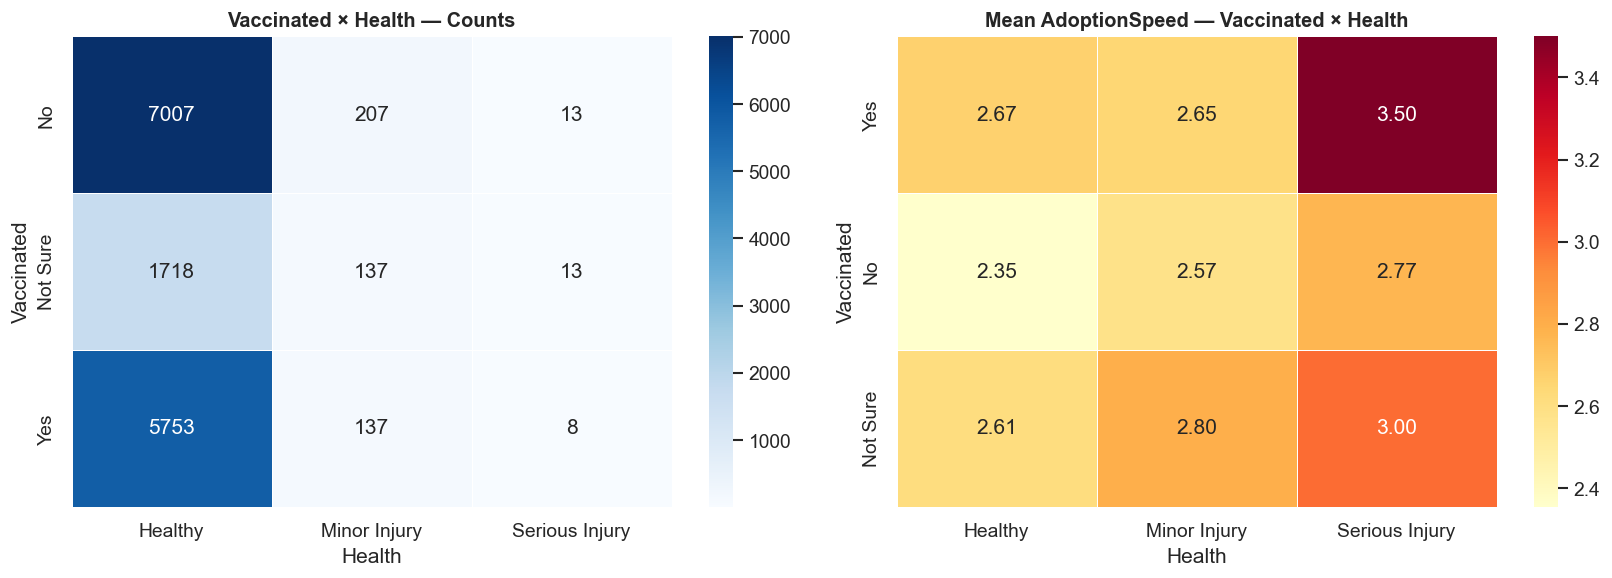


📝 Interaction hypotheses for future feature engineering:
  1. Age × Type — age distribution differs between dogs and cats by speed class
  2. Fee × State — fee effect on adoption speed varies across states
  3. Vaccinated × Health — vaccination status interacts with health in predicting speed


In [27]:
# ── Interaction 3: Vaccinated × Health ──────────────────────────────
vacc_health_labels = {1: "Yes", 2: "No", 3: "Not Sure"}
health_labels = {1: "Healthy", 2: "Minor Injury", 3: "Serious Injury"}

ct_vh = pd.crosstab(
    train["Vaccinated"].map(vacc_health_labels),
    train["Health"].map(health_labels),
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cross-tabulation heatmap
sns.heatmap(ct_vh, annot=True, fmt="d", cmap="Blues", ax=axes[0], linewidths=0.5)
axes[0].set_title("Vaccinated × Health — Counts", fontsize=12, fontweight="bold")

# Mean AdoptionSpeed by Vaccinated × Health
mean_speed_vh = train.groupby(["Vaccinated", "Health"])["AdoptionSpeed"].mean().unstack()
mean_speed_vh.index = mean_speed_vh.index.map(vacc_health_labels)
mean_speed_vh.columns = mean_speed_vh.columns.map(health_labels)
sns.heatmap(mean_speed_vh, annot=True, fmt=".2f", cmap="YlOrRd", ax=axes[1], linewidths=0.5)
axes[1].set_title("Mean AdoptionSpeed — Vaccinated × Health", fontsize=12, fontweight="bold")

fig.tight_layout()
saved_figures.append(save_figure(fig, "interaction_vaccinated_health"))
plt.show()

print("\n📝 Interaction hypotheses for future feature engineering:")
print("  1. Age × Type — age distribution differs between dogs and cats by speed class")
print("  2. Fee × State — fee effect on adoption speed varies across states")
print("  3. Vaccinated × Health — vaccination status interacts with health in predicting speed")

---
## 16. Outlier Summary

Consolidated view of all outliers detected in numeric features (documentation only — no transformations applied).

In [28]:
# ── Consolidated outlier summary ────────────────────────────────────
outlier_df["recommendation"] = [
    "Investigate — extreme ages may be data entry errors",
    "Investigate — high fees are rare; consider capping for modeling",
    "Expected — group listings; keep as-is",
    "Keep — natural variation in photo count",
    "Keep — most pets have 0 videos; sparse but valid",
]

display(outlier_df.style.format({
    "Q1": "{:.1f}", "Q3": "{:.1f}", "IQR": "{:.1f}",
    "lower_bound": "{:.1f}", "upper_bound": "{:.1f}",
    "pct_outliers": "{:.1f}%",
}).set_caption("Outlier Summary — Numeric Features (IQR Method)"))

,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers,pct_outliers,recommendation
feature,,,,,,,,
Age,2.0,12.0,10.0,-13.0,27.0,1501,10.0%,Investigate — extreme ages may be data entry errors
Fee,0.0,0.0,0.0,0.0,0.0,2330,15.5%,Investigate — high fees are rare; consider capping for modeling
Quantity,1.0,1.0,0.0,1.0,1.0,3428,22.9%,Expected — group listings; keep as-is
PhotoAmt,2.0,5.0,3.0,-2.5,9.5,922,6.2%,Keep — natural variation in photo count
VideoAmt,0.0,0.0,0.0,0.0,0.0,574,3.8%,Keep — most pets have 0 videos; sparse but valid


---
## 17. Figure Persistence & Findings Report

Compilation of the structured findings report in JSON.

In [39]:
# ── Compile findings report ─────────────────────────────────────────
findings = {
    "notebook": "04_eda_tabular",
    "dataset": "data/cleaned/train.parquet",
    "n_rows": int(len(train)),
    "n_columns": int(len(train.columns)),
    "target_distribution": {
        int(k): {"count": int(v), "proportion": round(v / len(train), 4)}
        for k, v in train["AdoptionSpeed"].value_counts().sort_index().items()
    },
    "imbalance_ratio": round(float(imbalance_ratio), 2),
    "descriptive_stats": {
        col: {stat: round(float(val), 4) for stat, val in row.items()}
        for col, row in desc_stats.iterrows()
    },
    "outlier_summary": {
        row["feature"] if "feature" in row else idx: {
            "n_outliers": int(row["n_outliers"]),
            "pct_outliers": float(row["pct_outliers"]),
            "upper_bound": float(row["upper_bound"]),
        }
        for idx, row in outlier_df.reset_index().iterrows()
    },
    "notable_correlations": {
        "pearson": [
            {"pair": f"{c1} × {c2}", "value": round(float(train[[c1, c2]].corr().iloc[0, 1]), 4)}
            for c1 in NUMERIC_COLS for c2 in NUMERIC_COLS
            if c1 < c2 and abs(train[[c1, c2]].corr().iloc[0, 1]) > 0.2
        ],
        "cramers_v_notable": [
            {"pair": f"{cat_for_cramer[i]} × {cat_for_cramer[j]}",
             "value": round(float(cramers_matrix.iloc[i, j]), 4)}
            for i in range(len(cat_for_cramer))
            for j in range(i + 1, len(cat_for_cramer))
            if cramers_matrix.iloc[i, j] > 0.15
        ],
    },
    "breed_analysis": {
        "mixed_breed_pct": round(float(train["is_mixed"].mean() * 100), 2),
        "n_unique_breed1": int(train["Breed1"].nunique()),
    },
    "fee_analysis": {
        "free_pct": round(float((train["Fee"] == 0).mean() * 100), 2),
        "paid_median": float(train.loc[train["Fee"] > 0, "Fee"].median()),
    },
    "rescuer_analysis": {
        "n_unique_rescuers": int(train["RescuerID"].nunique()),
        "listings_per_rescuer_median": float(rescuer_stats["n_listings"].median()),
        "max_listings_single_rescuer": int(rescuer_stats["n_listings"].max()),
    },
    "name_analysis": {
        "valid_name_pct": round(float(has_name_pct), 2),
        "n_unique_names": int(n_unique),
        "n_repeated_names": int(n_repeated),
        "noisy_count": int(noisy_count + name_null),
    },
    "interaction_hypotheses": [
        "Age × Type — age distributions differ between dogs and cats across speed classes",
        "Fee × State — fee impact on adoption speed varies by geographic region",
        "Vaccinated × Health — vaccination interacts with health condition in speed prediction",
    ],
    "figures_saved": len(saved_figures),
}

# ── Persist findings ───────────────────────────────────────────────
print(f"   Total figures saved: {len(saved_figures)}")

findings_path = cfg.REPORTS_DIR / "eda_tabular_findings.json"
with open(findings_path, "w", encoding="utf-8") as f:
    json.dump(findings, f, indent=2, ensure_ascii=False)

print(f"✅ Findings report saved: {findings_path}")

   Total figures saved: 50
✅ Findings report saved: C:\Projects\Personal_Projects\AI_Adoption_Acceleration\adoption_accelerator\reports\eda_tabular_findings.json


---
## 18. Validation Gate

Formal verification of all G04 checkpoint gates.

In [40]:
# ══════════════════════════════════════════════════════════════════════
#  VALIDATION GATE — G04
# ══════════════════════════════════════════════════════════════════════

gate_results = []

# G04-1: Cleaned train data loaded with expected shape and columns
try:
    assert len(train) > 0, "Train is empty"
    assert len(missing_cols) == 0, f"Missing columns: {missing_cols}"
    gate_results.append(("G04-1", "PASS", "Cleaned data loaded — shape and columns OK"))
except AssertionError as e:
    gate_results.append(("G04-1", "FAIL ❌", str(e)))

# G04-2: All 5 AdoptionSpeed classes present
try:
    assert classes_present == {0, 1, 2, 3, 4}
    gate_results.append(("G04-2", "PASS", "All 5 classes present"))
except AssertionError:
    gate_results.append(("G04-2", "FAIL ❌", f"Classes found: {classes_present}"))

# G04-3: At least one figure saved per analysis section
n_expected_sections = 13  # sections 3 through 15 (including Name Analysis)
if len(saved_figures) >= n_expected_sections:
    gate_results.append(("G04-3", "PASS", f"{len(saved_figures)} figures saved"))
else:
    gate_results.append(("G04-3", "WARN ⚠️", f"Only {len(saved_figures)} figures saved"))

# G04-4: No NaN values introduced during analysis
# Check only the original columns that were present before analysis
original_cols = list(EXPECTED_COLS)
final_nan_count = int(train[original_cols].isna().sum().sum())
try:
    assert final_nan_count == initial_nan_count, (
        f"NaN count changed: {initial_nan_count} → {final_nan_count}"
    )
    gate_results.append(("G04-4", "PASS", "Data integrity preserved — no NaN introduced"))
except AssertionError as e:
    gate_results.append(("G04-4", "FAIL ❌", str(e)))

# G04-5: Findings report persisted
try:
    assert findings_path.exists(), f"File not found: {findings_path}"
    gate_results.append(("G04-5", "PASS", f"Report saved at {findings_path}"))
except AssertionError as e:
    gate_results.append(("G04-5", "WARN ⚠️", str(e)))

# ── Print gate summary ─────────────────────────────────────────────
print("=" * 65)
print("  VALIDATION GATE — G04 RESULTS")
print("=" * 65)
for gid, status, msg in gate_results:
    icon = "✅" if status == "PASS" else "⚠️" if "WARN" in status else "❌"
    print(f"  {icon} {gid}: [{status}] {msg}")

passed = sum(1 for _, s, _ in gate_results if s == "PASS")
total = len(gate_results)
print(f"\n  Result: {passed}/{total} gates passed.")
print("=" * 65)

# Halt on critical failures
critical_failures = [g for g in gate_results if "FAIL" in g[1] and g[0] in ("G04-1", "G04-2", "G04-4")]
assert len(critical_failures) == 0, f"Critical gate failures: {critical_failures}"

  VALIDATION GATE — G04 RESULTS
  ✅ G04-1: [PASS] Cleaned data loaded — shape and columns OK
  ✅ G04-2: [PASS] All 5 classes present
  ✅ G04-3: [PASS] 50 figures saved
  ✅ G04-4: [PASS] Data integrity preserved — no NaN introduced
  ✅ G04-5: [PASS] Report saved at C:\Projects\Personal_Projects\AI_Adoption_Acceleration\adoption_accelerator\reports\eda_tabular_findings.json

  Result: 5/5 gates passed.


---
## Summary

<div style="border-left: 4px solid #27ae60; padding: 10px 15px; margin: 10px 0; background: #232a3b;">

**Key findings from tabular EDA:**

1. **Target imbalance** — Class 2 (8–30 days) and Class 4 (100+ days) dominate; Class 0 (same day) is the minority. Imbalance must be handled during modeling.
2. **Age** — Younger animals tend to be adopted faster. Strong signal for prediction.
3. **Fee** — Free listings show different adoption patterns; Fee has discriminative value.
4. **Type** — Cats and dogs show different adoption speed profiles.
5. **Vaccinated / Dewormed / Sterilized** — Medical status columns show association with adoption speed.
6. **Breed** — Mixed breeds and specific breeds exhibit distinct adoption patterns.
7. **State** — Geographic concentration in Selangor and Kuala Lumpur; some states show significantly different adoption speeds.
8. **Rescuers** — High-volume rescuers exist; rescuer-level aggregations may be predictive.
9. **Name** — Significant proportion of listings lack a valid name; name presence shows association with adoption speed. Noisy patterns (placeholders, symbols, numeric-only) identified.
10. **Interaction hypotheses** — Age×Type, Fee×State, and Vaccinated×Health documented for future feature engineering.

</div>

**→ Next:** Notebook `05_eda_text_sentiment` (text and sentiment analysis) or `06_eda_images_metadata` (image analysis).